# MedGS interpolation experiment — v3

This notebook uses cases prepared by
`01_inspect_4d_lung_and_prepare_split_v4.ipynb`.

Relative to `02_train_evaluate_medgs_interpolation_v1.ipynb`, this version adds:

1. reconstruction metrics for the observed training slices;
2. a nested pseudo-held-out experiment created only from the original training
   split;
3. optional supervision with actual CT midpoint slices in the MedGS
   interpolation loss;
4. a DICOM-ordered single-view mode that removes the synthetic mirror camera;
5. an independent comparison of `poly_degree=1` and `poly_degree=2`;
6. optional three-window CT encoding in RGB;
7. a proper ablation study in which every structural modification is tested
   independently against one common nested baseline;
8. a slice-role plot showing direct support frames, pseudo-loss supervision
   midpoints, pseudo-validation midpoints, the official test split, and any
   original training slice unused by the nested split;
9. an aggregate ablation results table, an interactive result browser, and a
   final experiment controlled by explicit feature switches.

The official test DICOM slices remain hidden from training.

The pseudo-held-out experiments use a separate evaluation scope. A sparse
support sequence is created from the notebook-01 training split. Midpoint
intervals are then divided into two disjoint groups:

- alternating midpoint intervals provide actual CT supervision;
- the remaining midpoint intervals are used only for pseudo-validation.

Consequently, actual midpoint slices used in the pseudo-loss are never used to
compute the reported pseudo-validation metrics. Results from `official_test`
and `pseudo_holdout` must not be compared as if they used identical training
and evaluation data.

“DICOM geometry” in this notebook means the conservative correction supported
by the current MedGS implementation: physical DICOM ordering and regular
spacing are verified, and the artificial mirror camera is replaced by one fixed
view. For a parallel, regularly spaced stack, normalized frame position is an
affine transformation of physical `z`. This is not a new CT forward projector
or a full orthographic Gaussian rasterizer.

`lpips` is required but is not installed automatically. When it is absent,
install it once in the active MedGS kernel:

```python
%pip install lpips
```

Restart the kernel after installation.

The original single-run workflow remains available as the official-test
baseline. Existing completed runs are reused by default.

---

## Helios quick reference

Three operations are required to start JupyterLab:

1. start an interactive Slurm allocation;
2. activate the environment and start JupyterLab on the allocated compute node;
3. create an SSH tunnel from the local computer.

### 1. Connect to Helios and start a GH200 allocation

Run on the local computer:

```bash
ssh <PLGRID_LOGIN>@login01.helios.cyfronet.pl
```

Then request an interactive GH200 allocation on the Helios login node:

```bash
srun \
  --account=plgunhype-gpu-gh200 \
  --partition=plgrid-gpu-gh200 \
  --nodes=1 \
  --ntasks=1 \
  --cpus-per-task=8 \
  --mem=64G \
  --gres=gpu:1 \
  --time=04:00:00 \
  --pty bash -i
```

After the allocation starts, verify that the shell is running on the compute
node:

```bash
hostname
uname -m
echo "$SLURM_JOB_ID"
```

The architecture should be `aarch64`. Copy the hostname returned by `hostname`,
for example `x1002c0s6b1n0`; it is required by the SSH tunnel.

### 2. Activate the MedGS environment and start JupyterLab

Run inside the active Slurm allocation:

```bash
USER_PROJECT_ROOT="/net/storage/pr3/plgrid/plggtriplane/${USER}/medgs4d"
ENV_ROOT="$USER_PROJECT_ROOT/envs/medgs-gh200"

module purge
module load Python/3.11.5
module load CUDA/12.8.0

source "$ENV_ROOT/bin/activate"

jupyter lab \
  --no-browser \
  --ip=0.0.0.0 \
  --port=8888 \
  --ServerApp.port_retries=0 \
  --ServerApp.root_dir="$USER_PROJECT_ROOT"
```

Keep this terminal open. JupyterLab and the notebook kernel run on the allocated
GH200 compute node.

### 3. Create the SSH tunnel

Run in a second terminal on the local computer:

```bash
ssh -N \
  -o ExitOnForwardFailure=yes \
  -o ServerAliveInterval=60 \
  -L 8888:<COMPUTE_NODE>:8888 \
  <PLGRID_LOGIN>@login01.helios.cyfronet.pl
```

Replace:

- `<PLGRID_LOGIN>` with the PLGrid login;
- `<COMPUTE_NODE>` with the hostname returned by `hostname` inside the
  allocation.

Open locally:

```text
http://localhost:8888
```

### Additional shell in the same allocation

Connect again to the Helios login node:

```bash
ssh <PLGRID_LOGIN>@login01.helios.cyfronet.pl
```

Find the active job:

```bash
squeue -u "$USER" -o "%.18i %.10T %.20j %.30R"
```

Open another shell in the same allocation:

```bash
srun \
  --jobid=<JOB_ID> \
  --overlap \
  --nodes=1 \
  --ntasks=1 \
  --cpus-per-task=1 \
  --pty bash -i
```

Replace `<JOB_ID>` with the identifier displayed by `squeue`.

GPU monitoring:

```bash
watch -n 1 nvidia-smi
```

Detailed utilization monitoring:

```bash
nvidia-smi dmon -s pucm -d 1
```

In [1]:
import sys

print(sys.executable)

/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/envs/medgs-gh200/bin/python


In [2]:
from __future__ import annotations

print("Importing libraries used by the MedGS experiment.")

import json
import os
import re
import shlex
import shutil
import subprocess
import sys
from pathlib import Path
import lpips
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
import torch
from IPython.display import display
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 500)

Importing libraries used by the MedGS experiment.


## 1. Project paths and runtime

In [3]:
print("Defining project, prepared-case, and experiment paths.")

STORAGE_ROOT = Path("/net/storage/pr3/plgrid/plggtriplane")
PROJECT_OWNER_LOGIN = "plgmozo"

SHARED_PROJECT_ROOT = STORAGE_ROOT / PROJECT_OWNER_LOGIN / "medgs4d"
USER_PROJECT_ROOT = STORAGE_ROOT / os.environ["USER"] / "medgs4d"

SERIES_ZIPS_ROOT = SHARED_PROJECT_ROOT / "data" / "raw" / "series_zips"
DICOM_ROOT = SHARED_PROJECT_ROOT / "data" / "raw" / "dicom_by_series"
METADATA_ROOT = SHARED_PROJECT_ROOT / "data" / "metadata"
RESULTS_ROOT = USER_PROJECT_ROOT / "results"
LOGS_ROOT = USER_PROJECT_ROOT / "logs"
REPOSITORIES_ROOT = SHARED_PROJECT_ROOT / "repo"
ENVIRONMENTS_ROOT = SHARED_PROJECT_ROOT / "envs"
SHARED_RESULTS_ROOT = SHARED_PROJECT_ROOT / "results"
SHARED_LOGS_ROOT = SHARED_PROJECT_ROOT / "logs"
CASES_ROOT = RESULTS_ROOT / "prepared_cases"

MEDGS_REPOSITORY = REPOSITORIES_ROOT / "MedGS"
EXPERIMENTS_ROOT = RESULTS_ROOT / "experiments"

path_table = pd.DataFrame(
    [
        {"Purpose": "Prepared cases", "Path": CASES_ROOT},
        {"Purpose": "DICOM input", "Path": DICOM_ROOT},
        {"Purpose": "MedGS repository", "Path": MEDGS_REPOSITORY},
        {"Purpose": "Experiment outputs", "Path": EXPERIMENTS_ROOT},
    ]
)

display(path_table)

Defining project, prepared-case, and experiment paths.


,Purpose,Path
0,Prepared cases,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/prepared_cases
1,DICOM input,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series
2,MedGS repository,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/repo/MedGS
3,Experiment outputs,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments


In [4]:
print("Checking the active Python kernel and GPU.")

runtime_df = pd.DataFrame(
    [
        {"Item": "Python executable", "Value": sys.executable},
        {"Item": "Slurm job", "Value": os.environ.get("SLURM_JOB_ID", "")},
        {"Item": "CUDA available", "Value": torch.cuda.is_available()},
        {"Item": "GPU", "Value": torch.cuda.get_device_name(0)},
        {"Item": "PyTorch", "Value": torch.__version__},
    ]
)

display(runtime_df)

Checking the active Python kernel and GPU.


,Item,Value
0,Python executable,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/envs/medgs-gh200/bin/python
1,Slurm job,19695387
2,CUDA available,True
3,GPU,NVIDIA GH200 120GB
4,PyTorch,2.7.1+cu128


## 2. List prepared experiment configurations

In [5]:
print("Listing all prepared experiment configurations.")

configuration_rows = []

for config_directory in sorted(
        path for path in CASES_ROOT.iterdir() if path.is_dir()
):
    case_files = sorted(config_directory.glob("*/case.json"))

    if not case_files:
        continue

    cases = [
        json.loads(case_file.read_text(encoding="utf-8"))
        for case_file in case_files
    ]

    patients = {case["patient_id"] for case in cases}
    phases = sorted({float(case["phase_percent"]) for case in cases})

    configuration_rows.append(
        {
            "ConfigName": config_directory.name,
            "PreparedCases": len(cases),
            "Patients": len(patients),
            "Phases": ", ".join(f"{phase:g}%" for phase in phases),
            "TotalTrainSlices": sum(
                int(case["train_slice_count"]) for case in cases
            ),
            "TotalTestSlices": sum(
                int(case["test_slice_count"]) for case in cases
            ),
            "Directory": str(config_directory),
        }
    )

prepared_configurations_df = (
    pd.DataFrame(configuration_rows)
    .sort_values("ConfigName")
    .reset_index(drop=True)
)

print(
    f"Prepared experiment configurations: "
    f"{len(prepared_configurations_df)}"
)
display(prepared_configurations_df)

Listing all prepared experiment configurations.
Prepared experiment configurations: 2


,ConfigName,PreparedCases,Patients,Phases,TotalTrainSlices,TotalTestSlices,Directory
0,single_phase_ct_every_second_slice_v1,1,1,20%,26,24,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/prepared_cases/single_phase_ct_every_second_slice_v1
1,single_phase_ct_every_second_slice_v4,1,1,20%,74,73,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/prepared_cases/single_phase_ct_every_second_slice_v4


## 3. Select a configuration and list its cases

Set `CONFIG_NAME` to one of the values displayed above.

In [6]:
print("Listing prepared cases for the selected configuration.")

CONFIG_NAME = "single_phase_ct_every_second_slice_v4"

config_directory = CASES_ROOT / CONFIG_NAME
case_rows = []

for case_config_path in sorted(config_directory.glob("*/case.json")):
    case_config = json.loads(
        case_config_path.read_text(encoding="utf-8")
    )

    case_rows.append(
        {
            "CaseName": case_config["resolved_case_name"],
            "PatientID": case_config["patient_id"],
            "StudyDate": case_config["study_date"],
            "PhasePercent": case_config["phase_percent"],
            "Slices": case_config["slice_count"],
            "Train": case_config["train_slice_count"],
            "Test": case_config["test_slice_count"],
            "SeriesDescription": case_config["series_description"],
            "CaseDirectory": str(case_config_path.parent),
        }
    )

prepared_cases_df = (
    pd.DataFrame(case_rows)
    .sort_values(["PatientID", "StudyDate", "CaseName"])
    .reset_index(drop=True)
)

print(
    f"Prepared cases for configuration {CONFIG_NAME}: "
    f"{len(prepared_cases_df)}"
)
display(prepared_cases_df)

Listing prepared cases for the selected configuration.
Prepared cases for configuration single_phase_ct_every_second_slice_v4: 1


,CaseName,PatientID,StudyDate,PhasePercent,Slices,Train,Test,SeriesDescription,CaseDirectory
0,single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587,117_HM10395,20001024,20.0,147,74,73,"P4^P117^S301^I00005, Gated, 20.0%A",/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/prepared_cases/single_phase_ct_every_second_slice_v4/si...


## 4. Load one prepared case

Set `SELECTED_CASE_NAME` explicitly using a name from the table above.

In [7]:
print("Loading the selected prepared case for training and evaluation.")

SELECTED_CASE_NAME = (
    "single_phase_ct_every_second_slice_v4"
    "__117_HM10395"
    "__phase_20"
    "__series_476677184587"
)

selected_case_directory = (
        CASES_ROOT / CONFIG_NAME / SELECTED_CASE_NAME
)

loaded_case_config = json.loads(
    (selected_case_directory / "case.json").read_text(
        encoding="utf-8"
    )
)

split_manifest_df = pd.read_csv(
    selected_case_directory
    / loaded_case_config["manifest_file"]
)

split_manifest_df["Path"] = split_manifest_df[
    "DICOMRelativePath"
].map(lambda value: str(DICOM_ROOT / value))

split_manifest_df = split_manifest_df.sort_values(
    "SliceIndex"
).reset_index(drop=True)

train_manifest_df = (
    split_manifest_df.loc[
        split_manifest_df["Split"] == "train"
        ]
    .sort_values("SliceIndex")
    .reset_index(drop=True)
)

test_manifest_df = (
    split_manifest_df.loc[
        split_manifest_df["Split"] == "test"
        ]
    .sort_values("SliceIndex")
    .reset_index(drop=True)
)

PATIENT_ID = loaded_case_config["patient_id"]
TARGET_PHASE_PERCENT = float(
    loaded_case_config["phase_percent"]
)
HU_WINDOW_LOW = float(loaded_case_config["hu_window_low"])
HU_WINDOW_HIGH = float(loaded_case_config["hu_window_high"])
selected_study_uid = loaded_case_config["study_instance_uid"]
selected_series_uid = loaded_case_config["series_instance_uid"]
selected_series_dir = (
        DICOM_ROOT / loaded_case_config["series_relative_path"]
)
resolved_case_name = loaded_case_config["resolved_case_name"]

print(f"Case name:         {resolved_case_name}")
print(f"Patient ID:        {PATIENT_ID}")
print(f"Study date:        {loaded_case_config['study_date']}")
print(f"Study UID:         {selected_study_uid}")
print(f"Series UID:        {selected_series_uid}")
print(f"Respiratory phase: {TARGET_PHASE_PERCENT:g}%")
print(
    f"HU window:         "
    f"[{HU_WINDOW_LOW:g}, {HU_WINDOW_HIGH:g}]"
)
print(f"Train slices:      {len(train_manifest_df)}")
print(f"Test slices:       {len(test_manifest_df)}")
print(f"Series directory:  {selected_series_dir}")

display(
    split_manifest_df[
        [
            "SliceIndex",
            "Split",
            "SliceCoordinate",
            "LowerTrainCoordinate",
            "UpperTrainCoordinate",
            "File",
        ]
    ]
)

Loading the selected prepared case for training and evaluation.
Case name:         single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587
Patient ID:        117_HM10395
Study date:        20001024
Study UID:         1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180
Series UID:        1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587
Respiratory phase: 20%
HU window:         [-1000, 400]
Train slices:      74
Test slices:       73
Series directory:  /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587


,SliceIndex,Split,SliceCoordinate,LowerTrainCoordinate,UpperTrainCoordinate,File
0,0,train,-266.2,-266.2,-266.2,00000016.dcm
1,1,test,-263.2,-266.2,-260.2,00000087.dcm
2,2,train,-260.2,-260.2,-260.2,00000045.dcm
3,3,test,-257.2,-260.2,-254.2,00000033.dcm
4,4,train,-254.2,-254.2,-254.2,00000088.dcm
5,5,test,-251.2,-254.2,-248.2,00000139.dcm
6,6,train,-248.2,-248.2,-248.2,00000036.dcm
7,7,test,-245.2,-248.2,-242.2,00000031.dcm
8,8,train,-242.2,-242.2,-242.2,00000019.dcm
9,9,test,-239.2,-242.2,-236.2,00000082.dcm


## 5. Baseline experiment settings

The v4 baseline uses 30,000 training iterations. MedGS enables its
in-between-frame interpolation stage after 10,000 iterations, so a shorter
smoke test does not exercise the full procedure.

Set `RUN_TRAINING=True` and `RUN_RENDERING=True` only when the baseline artifacts do not yet exist.

Change `RUN_NAME` whenever intentionally training a different baseline.

In [8]:
print("Defining MedGS training and rendering settings.")

ITERATIONS = 30_000
POLY_DEGREE = 2
BATCH_SIZE = 3
CAMERA = "mirror"
RENDER_INTERPOLATION = 2

RUN_TRAINING = False
RUN_RENDERING = False

RUN_NAME = f"medgs_img_poly{POLY_DEGREE}_{ITERATIONS}_v4"

RUN_ROOT = (
        EXPERIMENTS_ROOT
        / CONFIG_NAME
        / SELECTED_CASE_NAME
        / RUN_NAME
)
MEDGS_DATASET_ROOT = RUN_ROOT / "dataset"
ORIGINAL_IMAGES_ROOT = MEDGS_DATASET_ROOT / "original"
MIRROR_IMAGES_ROOT = MEDGS_DATASET_ROOT / "mirror"
MODEL_ROOT = RUN_ROOT / "model"
RENDER_ROOT = MODEL_ROOT / "render_img"

TRAIN_SCRIPT = MEDGS_REPOSITORY / "train.py"
RENDER_SCRIPT = MEDGS_REPOSITORY / "render.py"

METRICS_PATH = RUN_ROOT / "metrics.csv"
RUN_CONFIG_PATH = RUN_ROOT / "run.json"

RUN_ROOT.mkdir(parents=True, exist_ok=True)

settings_df = pd.DataFrame(
    [
        {"Setting": "Run name", "Value": RUN_NAME},
        {"Setting": "Iterations", "Value": ITERATIONS},
        {"Setting": "Polynomial degree", "Value": POLY_DEGREE},
        {"Setting": "Batch size", "Value": BATCH_SIZE},
        {"Setting": "Camera", "Value": CAMERA},
        {
            "Setting": "Render interpolation",
            "Value": RENDER_INTERPOLATION,
        },
        {"Setting": "Dataset", "Value": MEDGS_DATASET_ROOT},
        {"Setting": "Model output", "Value": MODEL_ROOT},
    ]
)

display(settings_df)

Defining MedGS training and rendering settings.


,Setting,Value
0,Run name,medgs_img_poly2_30000_v4
1,Iterations,30000
2,Polynomial degree,2
3,Batch size,3
4,Camera,mirror
5,Render interpolation,2
6,Dataset,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
7,Model output,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...


## 6. Convert training DICOM slices to MedGS input

In [9]:
print("Converting only training CT slices to HU-windowed MedGS PNG frames.")


def read_hu_image(path: Path) -> np.ndarray:
    """Read one CT slice and convert stored values to Hounsfield units."""

    dataset = pydicom.dcmread(str(path), force=True)
    pixels = dataset.pixel_array.astype(np.float32)
    slope = float(getattr(dataset, "RescaleSlope", 1.0))
    intercept = float(getattr(dataset, "RescaleIntercept", 0.0))
    return pixels * slope + intercept


def window_hu(
        image_hu: np.ndarray,
        low: float,
        high: float,
) -> np.ndarray:
    """Clip an HU image to one window and normalize it to [0, 1]."""

    clipped = np.clip(image_hu, low, high)
    return (clipped - low) / (high - low)


def grayscale_to_rgb_uint8(image: np.ndarray) -> np.ndarray:
    """Convert a normalized grayscale image to three-channel uint8 RGB."""

    grayscale = np.round(image * 255.0).astype(np.uint8)
    return np.repeat(grayscale[..., None], 3, axis=2)


shutil.rmtree(MEDGS_DATASET_ROOT, ignore_errors=True)
ORIGINAL_IMAGES_ROOT.mkdir(parents=True)
MIRROR_IMAGES_ROOT.mkdir(parents=True)

frame_rows = []

for frame_index, row in train_manifest_df.iterrows():
    normalized = window_hu(
        read_hu_image(Path(row["Path"])),
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )
    rgb = grayscale_to_rgb_uint8(normalized)

    filename = f"{frame_index:04d}.png"
    original_path = ORIGINAL_IMAGES_ROOT / filename
    mirror_path = MIRROR_IMAGES_ROOT / filename

    Image.fromarray(rgb).save(original_path)
    Image.fromarray(np.fliplr(rgb)).save(mirror_path)

    frame_rows.append(
        {
            "FrameIndex": frame_index,
            "SliceIndex": int(row["SliceIndex"]),
            "SliceCoordinate": float(row["SliceCoordinate"]),
            "DICOMRelativePath": row["DICOMRelativePath"],
            "OriginalPNG": str(original_path),
            "MirrorPNG": str(mirror_path),
        }
    )

frame_manifest_df = pd.DataFrame(frame_rows)

print(f"Training frames written: {len(frame_manifest_df)}")
print(f"Original directory:      {ORIGINAL_IMAGES_ROOT}")
print(f"Mirror directory:        {MIRROR_IMAGES_ROOT}")

display(
    frame_manifest_df[
        [
            "FrameIndex",
            "SliceIndex",
            "SliceCoordinate",
            "DICOMRelativePath",
        ]
    ]
)

Converting only training CT slices to HU-windowed MedGS PNG frames.
Training frames written: 74
Original directory:      /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/medgs_img_poly2_30000_v4/dataset/original
Mirror directory:        /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/medgs_img_poly2_30000_v4/dataset/mirror


,FrameIndex,SliceIndex,SliceCoordinate,DICOMRelativePath
0,0,0,-266.2,117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587/00000016.dcm
1,1,2,-260.2,117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587/00000045.dcm
2,2,4,-254.2,117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587/00000088.dcm
3,3,6,-248.2,117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587/00000036.dcm
4,4,8,-242.2,117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587/00000019.dcm
5,5,10,-236.2,117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587/00000117.dcm
6,6,12,-230.2,117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587/00000069.dcm
7,7,14,-224.2,117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587/00000040.dcm
8,8,16,-218.2,117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587/00000090.dcm
9,9,18,-212.2,117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587/00000007.dcm


## 7. Train MedGS

In [10]:
print("Running MedGS image reconstruction training.")

# Train the MedGS model for 30,000 updates on three images at a time, modeling the change between slices with a quadratic polynomial using the original and mirror images, and then generate one intermediate slice between each pair of training slices.

train_command = [
    sys.executable,
    str(TRAIN_SCRIPT),
    "-s",
    str(MEDGS_DATASET_ROOT),
    "-m",
    str(MODEL_ROOT),
    "--pipeline",
    "img",
    "--iterations",
    str(ITERATIONS),
    "--poly_degree",
    str(POLY_DEGREE),
    "--batch_size",
    str(BATCH_SIZE),
    "--camera",
    CAMERA,
    "--test_iterations",
    str(ITERATIONS),
    "--save_iterations",
    str(ITERATIONS),
    "--checkpoint_iterations",
    str(ITERATIONS),
]

print("Command:")
print(" ".join(shlex.quote(part) for part in train_command))

if RUN_TRAINING:
    if MODEL_ROOT.exists():
        raise FileExistsError(
            f"Model output already exists: {MODEL_ROOT}\n"
            "Change RUN_NAME before starting a new training run."
        )

    subprocess.run(
        train_command,
        cwd=MEDGS_REPOSITORY,
        check=True,
    )
else:
    print("Training skipped; the existing model output will be used.")

Running MedGS image reconstruction training.
Command:
/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/envs/medgs-gh200/bin/python /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/repo/MedGS/train.py -s /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/medgs_img_poly2_30000_v4/dataset -m /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/medgs_img_poly2_30000_v4/model --pipeline img --iterations 30000 --poly_degree 2 --batch_size 3 --camera mirror --test_iterations 30000 --save_iterations 30000 --checkpoint_iterations 30000
Training skipped; the existing model output will be used.


## 8. Render training frames and midpoint reconstructions

In [11]:
print("Rendering trained frames and one midpoint between adjacent frames.")

render_command = [
    sys.executable,
    str(RENDER_SCRIPT),
    "--model_path",
    str(MODEL_ROOT),
    "--iteration",
    "-1",
    "--interp",
    str(RENDER_INTERPOLATION),
    "--pipeline",
    "img",
    "--camera",
    CAMERA,
    "--poly_degree",
    str(POLY_DEGREE),
    "--chunks",
    "1",
]

print("Command:")
print(" ".join(shlex.quote(part) for part in render_command))

if RUN_RENDERING:
    shutil.rmtree(RENDER_ROOT, ignore_errors=True)

    subprocess.run(
        render_command,
        cwd=MEDGS_REPOSITORY,
        check=True,
    )
else:
    print("Rendering skipped; the existing render directory will be used.")

rendered_files = sorted(RENDER_ROOT.glob("*.png"))

print(f"Rendered PNG files: {len(rendered_files)}")
print(f"Render directory:   {RENDER_ROOT}")

Rendering trained frames and one midpoint between adjacent frames.
Command:
/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/envs/medgs-gh200/bin/python /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/repo/MedGS/render.py --model_path /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/medgs_img_poly2_30000_v4/model --iteration -1 --interp 2 --pipeline img --camera mirror --poly_degree 2 --chunks 1
Rendering skipped; the existing render directory will be used.
Rendered PNG files: 148
Render directory:   /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/medgs_img_poly2_30000_v4/model/render_img


## 9. Match rendered midpoints to held-out CT slices

With `--interp 2`, MedGS writes `_0` for the trained frame and `_1`
for the midpoint toward the next trained frame.

The `mirror` camera pipeline may render two camera views per frame.
This cell detects whether the renderer produced one or two views per
training frame and, when necessary, identifies the non-mirrored view.

In [12]:
print("Matching MedGS midpoint renders to held-out test slices.")


def load_png_gray(path: Path) -> np.ndarray:
    """Load a PNG as a normalized grayscale float array."""

    return np.asarray(
        Image.open(path).convert("L"),
        dtype=np.float32,
    ) / 255.0


base_render_files = sorted(RENDER_ROOT.glob("*_0.png"))
rendered_view_count = len(base_render_files)
training_frame_count = len(frame_manifest_df)

if rendered_view_count == training_frame_count:
    camera_stride = 1
    original_camera_offset = 0
elif rendered_view_count == 2 * training_frame_count:
    camera_stride = 2

    first_input = load_png_gray(
        Path(frame_manifest_df.iloc[0]["OriginalPNG"])
    )
    first_view = load_png_gray(RENDER_ROOT / "00000_0.png")
    second_view = load_png_gray(RENDER_ROOT / "00001_0.png")

    first_error = np.mean((first_view - first_input) ** 2)
    second_error = np.mean((second_view - first_input) ** 2)

    original_camera_offset = int(second_error < first_error)
else:
    raise RuntimeError(
        f"Unexpected rendered view count: {rendered_view_count}. "
        f"Training frames: {training_frame_count}."
    )

coordinate_to_frame = dict(
    zip(
        frame_manifest_df["SliceCoordinate"],
        frame_manifest_df["FrameIndex"],
    )
)

reconstruction_rows = []

for _, row in test_manifest_df.iterrows():
    lower_coordinate = float(row["LowerTrainCoordinate"])
    upper_coordinate = float(row["UpperTrainCoordinate"])
    target_coordinate = float(row["SliceCoordinate"])
    expected_midpoint = 0.5 * (
            lower_coordinate + upper_coordinate
    )

    if not np.isclose(target_coordinate, expected_midpoint):
        raise ValueError(
            f"Slice {row['SliceIndex']} is not the midpoint between "
            f"its neighbouring training slices."
        )

    lower_frame_index = int(
        coordinate_to_frame[lower_coordinate]
    )
    upper_frame_index = int(
        coordinate_to_frame[upper_coordinate]
    )

    render_view_index = (
            original_camera_offset
            + camera_stride * lower_frame_index
    )
    reconstruction_path = (
            RENDER_ROOT / f"{render_view_index:05d}_1.png"
    )

    reconstruction_rows.append(
        {
            "SliceIndex": int(row["SliceIndex"]),
            "SliceCoordinate": target_coordinate,
            "GroundTruthPath": row["Path"],
            "LowerTrainFrame": lower_frame_index,
            "UpperTrainFrame": upper_frame_index,
            "LowerTrainPath": train_manifest_df.loc[
                train_manifest_df["SliceCoordinate"]
                == lower_coordinate,
                "Path",
            ].iloc[0],
            "UpperTrainPath": train_manifest_df.loc[
                train_manifest_df["SliceCoordinate"]
                == upper_coordinate,
                "Path",
            ].iloc[0],
            "ReconstructionPath": str(reconstruction_path),
        }
    )

reconstruction_manifest_df = pd.DataFrame(
    reconstruction_rows
).sort_values("SliceIndex").reset_index(drop=True)

print(f"Rendered views per training frame: {camera_stride}")
print(f"Original camera offset:           {original_camera_offset}")
print(
    f"Matched test reconstructions:      "
    f"{len(reconstruction_manifest_df)}"
)

display(reconstruction_manifest_df)

Matching MedGS midpoint renders to held-out test slices.
Rendered views per training frame: 1
Original camera offset:           0
Matched test reconstructions:      73


,SliceIndex,SliceCoordinate,GroundTruthPath,LowerTrainFrame,UpperTrainFrame,LowerTrainPath,UpperTrainPath,ReconstructionPath
0,1,-263.2,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,0,1,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
1,3,-257.2,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,1,2,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
2,5,-251.2,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,2,3,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
3,7,-245.2,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,3,4,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
4,9,-239.2,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,4,5,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
5,11,-233.2,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,5,6,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
6,13,-227.2,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,6,7,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
7,15,-221.2,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,7,8,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.68...,/net/storage/pr3/plgrid/plggtrip

## 10. Compute reconstruction metrics

Metrics are calculated against the original held-out DICOM slices
after applying the same HU window used for training.

A linear midpoint interpolation between the neighbouring training
slices is evaluated as a baseline. LPIPS is calculated when the
`lpips` package is installed in the active kernel; otherwise its
columns contain `NaN`.

In [13]:
print("Computing MedGS and linear-interpolation metrics on test slices.")

lpips_model = lpips.LPIPS(net="alex").cuda().eval()
print("LPIPS enabled.")


def lpips_distance(
        reference: np.ndarray,
        prediction: np.ndarray,
) -> float:
    """Compute LPIPS for two normalized grayscale images."""

    if lpips_model is None:
        return float("nan")

    reference_tensor = (
            torch.from_numpy(reference)
            .float()
            .unsqueeze(0)
            .unsqueeze(0)
            .repeat(1, 3, 1, 1)
            .cuda()
            * 2.0
            - 1.0
    )
    prediction_tensor = (
            torch.from_numpy(prediction)
            .float()
            .unsqueeze(0)
            .unsqueeze(0)
            .repeat(1, 3, 1, 1)
            .cuda()
            * 2.0
            - 1.0
    )

    with torch.no_grad():
        return float(
            lpips_model(
                reference_tensor,
                prediction_tensor,
            ).item()
        )


metric_rows = []

for _, row in reconstruction_manifest_df.iterrows():
    ground_truth = window_hu(
        read_hu_image(Path(row["GroundTruthPath"])),
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )
    reconstruction = load_png_gray(
        Path(row["ReconstructionPath"])
    )

    lower_train = window_hu(
        read_hu_image(Path(row["LowerTrainPath"])),
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )
    upper_train = window_hu(
        read_hu_image(Path(row["UpperTrainPath"])),
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )
    linear_baseline = 0.5 * (
            lower_train + upper_train
    )

    metric_rows.append(
        {
            "SliceIndex": int(row["SliceIndex"]),
            "SliceCoordinate": float(row["SliceCoordinate"]),
            "MedGS_PSNR": peak_signal_noise_ratio(
                ground_truth,
                reconstruction,
                data_range=1.0,
            ),
            "MedGS_SSIM": structural_similarity(
                ground_truth,
                reconstruction,
                data_range=1.0,
            ),
            "MedGS_LPIPS": lpips_distance(
                ground_truth,
                reconstruction,
            ),
            "Linear_PSNR": peak_signal_noise_ratio(
                ground_truth,
                linear_baseline,
                data_range=1.0,
            ),
            "Linear_SSIM": structural_similarity(
                ground_truth,
                linear_baseline,
                data_range=1.0,
            ),
            "Linear_LPIPS": lpips_distance(
                ground_truth,
                linear_baseline,
            ),
            "ReconstructionPath": row["ReconstructionPath"],
        }
    )

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(METRICS_PATH, index=False)

metrics_summary_df = pd.DataFrame(
    [
        {
            "Method": "MedGS",
            "PSNR": metrics_df["MedGS_PSNR"].mean(),
            "SSIM": metrics_df["MedGS_SSIM"].mean(),
            "LPIPS": metrics_df["MedGS_LPIPS"].mean(),
        },
        {
            "Method": "Linear interpolation",
            "PSNR": metrics_df["Linear_PSNR"].mean(),
            "SSIM": metrics_df["Linear_SSIM"].mean(),
            "LPIPS": metrics_df["Linear_LPIPS"].mean(),
        },
    ]
)

print(f"Metrics saved to: {METRICS_PATH}")
display(metrics_summary_df)
display(metrics_df)

Computing MedGS and linear-interpolation metrics on test slices.
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/envs/medgs-gh200/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/envs/medgs-gh200/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/envs/medgs-gh200/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
LPIPS enabled.
Metrics saved to: /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/medgs_img_poly2_30000_v4/metrics.csv


,Method,PSNR,SSIM,LPIPS
0,MedGS,30.605865,0.797267,0.098635
1,Linear interpolation,30.343046,0.814462,0.065428


,SliceIndex,SliceCoordinate,MedGS_PSNR,MedGS_SSIM,MedGS_LPIPS,Linear_PSNR,Linear_SSIM,Linear_LPIPS,ReconstructionPath
0,1,-263.2,32.332635,0.824761,0.085952,33.009728,0.855648,0.058362,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
1,3,-257.2,31.047981,0.817278,0.086871,31.308189,0.838951,0.062341,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
2,5,-251.2,32.444469,0.833052,0.075315,33.026252,0.862406,0.055332,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
3,7,-245.2,32.722918,0.837875,0.071573,33.757975,0.872129,0.055065,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
4,9,-239.2,32.688526,0.822168,0.075686,33.269598,0.842070,0.050378,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
5,11,-233.2,30.866535,0.752611,0.114471,31.323999,0.790365,0.073945,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
6,13,-227.2,30.847450,0.743700,0.115638,31.281283,0.782805,0.079541,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
7,15,-221.2,29.871581,0.733633,0.113297,29.785731,0.757389,0.080913,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
8,17,-215.2,30.718659,0.732560,0.112088,31.076410,0.772821,0.073907,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
9,19,-209.2,30.784644,0.744857,0.121613,31.029983,0.769007,0.083924,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...


## 11. Training-slice reconstruction quality

Before interpreting midpoint interpolation, measure whether MedGS can reproduce
the slices that it actually observed. Render files ending in `_0.png` correspond
to observed frame positions. High training metrics together with poor midpoint
metrics indicate an interpolation problem rather than failure to fit the support
images.

In [14]:
print("Computing reconstruction quality on observed training slices.")

train_metric_rows = []

for _, frame in frame_manifest_df.iterrows():
    frame_index = int(frame["FrameIndex"])
    render_view_index = (
            original_camera_offset
            + camera_stride * frame_index
    )
    render_path = (
            RENDER_ROOT / f"{render_view_index:05d}_0.png"
    )

    reference = load_png_gray(
        Path(frame["OriginalPNG"])
    )
    prediction = load_png_gray(render_path)

    train_metric_rows.append(
        {
            "FrameIndex": frame_index,
            "SliceIndex": int(frame["SliceIndex"]),
            "SliceCoordinate": float(
                frame["SliceCoordinate"]
            ),
            "PSNR": peak_signal_noise_ratio(
                reference,
                prediction,
                data_range=1.0,
            ),
            "SSIM": structural_similarity(
                reference,
                prediction,
                data_range=1.0,
            ),
            "LPIPS": lpips_distance(
                reference,
                prediction,
            ),
            "RenderPath": str(render_path),
        }
    )

train_metrics_df = pd.DataFrame(train_metric_rows)
TRAIN_METRICS_PATH = RUN_ROOT / "train_metrics.csv"
train_metrics_df.to_csv(
    TRAIN_METRICS_PATH,
    index=False,
)

train_metrics_summary_df = pd.DataFrame(
    [
        {
            "Scope": "Observed training slices",
            "PSNR": train_metrics_df["PSNR"].mean(),
            "SSIM": train_metrics_df["SSIM"].mean(),
            "LPIPS": train_metrics_df["LPIPS"].mean(),
        }
    ]
)

print(f"Training metrics saved to: {TRAIN_METRICS_PATH}")
display(train_metrics_summary_df)
display(train_metrics_df)

Computing reconstruction quality on observed training slices.
Training metrics saved to: /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/medgs_img_poly2_30000_v4/train_metrics.csv


,Scope,PSNR,SSIM,LPIPS
0,Observed training slices,40.452961,0.963683,0.048926


,FrameIndex,SliceIndex,SliceCoordinate,PSNR,SSIM,LPIPS,RenderPath
0,0,0,-266.2,40.299632,0.967707,0.036092,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
1,1,2,-260.2,41.691895,0.972143,0.034321,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
2,2,4,-254.2,41.098369,0.961993,0.046076,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
3,3,6,-248.2,40.979917,0.970741,0.032091,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
4,4,8,-242.2,39.614970,0.966561,0.031684,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
5,5,10,-236.2,38.910990,0.950325,0.053114,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
6,6,12,-230.2,40.444813,0.954347,0.047450,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
7,7,14,-224.2,40.780807,0.956735,0.042638,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
8,8,16,-218.2,40.587895,0.957821,0.043786,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...
9,9,18,-212.2,39.685104,0.951935,0.049563,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...


## 12. Interactive train/reconstruction sequence

Training positions display the actual HU-windowed DICOM input.
Test positions display the corresponding MedGS reconstruction.

In [15]:
print("Creating a train/reconstruction slice browser.")

from IPython.display import clear_output, display

reconstruction_by_slice = {
    int(row["SliceIndex"]): row
    for _, row in metrics_df.iterrows()
}


def show_slice_side_by_side(slice_position: int) -> None:
    """Display one fixed-size horizontal comparison canvas."""

    row = split_manifest_df.iloc[slice_position]

    slice_index = int(row["SliceIndex"])
    coordinate = float(row["SliceCoordinate"])

    if row["Split"] == "train":
        left_image = window_hu(
            read_hu_image(Path(row["Path"])),
            HU_WINDOW_LOW,
            HU_WINDOW_HIGH,
        )

        right_image = np.ones_like(left_image)

        left_label = "Train input"
        right_label = ""

        title_line_1 = f"Slice {slice_index} | TRAIN INPUT"
        title_line_2 = (
            f"z={coordinate:.3f} mm | "
            f"HU [{HU_WINDOW_LOW:g}, {HU_WINDOW_HIGH:g}]"
        )

    else:
        metric_row = reconstruction_by_slice[slice_index]

        left_image = load_png_gray(
            Path(metric_row["ReconstructionPath"])
        )

        right_image = window_hu(
            read_hu_image(Path(row["Path"])),
            HU_WINDOW_LOW,
            HU_WINDOW_HIGH,
        )

        left_label = "Reconstructed"
        right_label = "Original test slice"

        title_line_1 = f"Slice {slice_index} | RECONSTRUCTION"
        title_line_2 = (
            f"z={coordinate:.3f} mm | "
            f"PSNR={metric_row['MedGS_PSNR']:.2f} | "
            f"SSIM={metric_row['MedGS_SSIM']:.4f} | "
            f"LPIPS={metric_row['MedGS_LPIPS']:.4f}"
        )

    separator_width = 16

    separator = np.ones(
        (left_image.shape[0], separator_width),
        dtype=np.float32,
    )

    comparison_image = np.concatenate(
        [
            left_image,
            separator,
            right_image,
        ],
        axis=1,
    )

    figure, axis = plt.subplots(figsize=(12, 6.4))

    axis.imshow(
        comparison_image,
        cmap="gray",
        vmin=0.0,
        vmax=1.0,
    )

    axis.axis("off")

    axis.text(
        0.25,
        1.02,
        left_label,
        transform=axis.transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
    )

    axis.text(
        0.75,
        1.02,
        right_label,
        transform=axis.transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
    )

    figure.suptitle(
        f"{title_line_1}\n{title_line_2}",
        fontsize=16,
        y=0.98,
    )

    figure.subplots_adjust(
        left=0.01,
        right=0.99,
        bottom=0.01,
        top=0.82,
    )

    plt.show()
    plt.close(figure)


side_by_side_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(split_manifest_df) - 1,
    step=1,
    description="Slice",
    continuous_update=False,
)

side_by_side_output = widgets.Output()


def update_side_by_side_browser(change=None) -> None:
    """Refresh the fixed comparison canvas."""

    with side_by_side_output:
        clear_output(wait=True)
        show_slice_side_by_side(side_by_side_slider.value)


side_by_side_slider.observe(
    update_side_by_side_browser,
    names="value",
)

display(side_by_side_slider, side_by_side_output)
update_side_by_side_browser()

Creating a train/reconstruction slice browser.


IntSlider(value=0, continuous_update=False, description='Slice', max=146)

Output()

## 13. Save the concise run record

In [16]:
print("Saving the experiment settings and aggregate results.")

run_record = {
    "schema_version": 2,
    "config_name": CONFIG_NAME,
    "case_name": SELECTED_CASE_NAME,
    "run_name": RUN_NAME,
    "case_config": str(
        selected_case_directory / "case.json"
    ),
    "split_manifest": str(
        selected_case_directory
        / loaded_case_config["manifest_file"]
    ),
    "dataset_root": str(MEDGS_DATASET_ROOT),
    "model_root": str(MODEL_ROOT),
    "render_root": str(RENDER_ROOT),
    "metrics_file": str(METRICS_PATH),
    "train_metrics_file": str(TRAIN_METRICS_PATH),
    "training": {
        "iterations": ITERATIONS,
        "poly_degree": POLY_DEGREE,
        "batch_size": BATCH_SIZE,
        "camera": CAMERA,
        "command": train_command,
    },
    "rendering": {
        "interpolation": RENDER_INTERPOLATION,
        "camera_stride": camera_stride,
        "original_camera_offset": original_camera_offset,
        "command": render_command,
    },
    "train_metrics_mean": {
        "PSNR": float(
            train_metrics_df["PSNR"].mean()
        ),
        "SSIM": float(
            train_metrics_df["SSIM"].mean()
        ),
        "LPIPS": float(
            train_metrics_df["LPIPS"].mean()
        ),
    },
    "metrics_mean": {
        row["Method"]: {
            "PSNR": (
                None if pd.isna(row["PSNR"])
                else float(row["PSNR"])
            ),
            "SSIM": (
                None if pd.isna(row["SSIM"])
                else float(row["SSIM"])
            ),
            "LPIPS": (
                None if pd.isna(row["LPIPS"])
                else float(row["LPIPS"])
            ),
        }
        for _, row in metrics_summary_df.iterrows()
    },
}

RUN_CONFIG_PATH.write_text(
    json.dumps(run_record, indent=2) + "\n",
    encoding="utf-8",
)

print(f"Run record: {RUN_CONFIG_PATH}")
print(f"Metrics:    {METRICS_PATH}")
print(f"Train data: {TRAIN_METRICS_PATH}")
print(f"Model:      {MODEL_ROOT}")

Saving the experiment settings and aggregate results.
Run record: /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/medgs_img_poly2_30000_v4/run.json
Metrics:    /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/medgs_img_poly2_30000_v4/metrics.csv
Train data: /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/medgs_img_poly2_30000_v4/train_metrics.csv
Model:      /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/medgs_img_po

## 14. Ablation study

The original run above remains the official-test baseline. The following
runs use a nested split created only from notebook-01 training slices.

Within that nested split:

- every second original training slice is used as a direct support frame;
- alternating midpoint intervals provide actual CT supervision;
- the remaining midpoint intervals form a disjoint pseudo-validation set.

Therefore, the actual midpoint images used by the pseudo-loss are never used
to compute the reported pseudo-validation metrics.

All ablation variants are compared with the same nested baseline:

- **B0 — nested baseline:** original linear-blend IBFR target, mirror camera,
  `poly_degree=2`, repeated grayscale;
- **B1 — pseudo-loss only:** B0 plus actual CT midpoint targets on supervision
  intervals;
- **B2 — DICOM single-view only:** B0 with the mirror camera removed and DICOM
  physical ordering retained;
- **B3 — polynomial degree only:** B0 with `poly_degree=1`;
- **B4 — multi-window RGB only:** B0 with three HU windows in RGB.

Thus, each comparison `B0` versus `B1`–`B4` isolates one change. The variants
are not cumulative. Every run also reports reconstruction quality on its direct
support slices.

In [17]:
print("Preparing disjoint pseudo-supervision and pseudo-validation intervals.")

nested_source_df = (
    train_manifest_df
    .sort_values("SliceCoordinate")
    .reset_index(drop=True)
)

pseudo_target_positions = list(
    range(1, len(nested_source_df) - 1, 2)
)
pseudo_support_positions = sorted(
    {
        neighbour
        for position in pseudo_target_positions
        for neighbour in (
        position - 1,
        position + 1,
    )
    }
)

pseudo_support_manifest_df = (
    nested_source_df.iloc[
        pseudo_support_positions
    ]
    .copy()
    .reset_index(drop=True)
)

pseudo_target_rows = []

for pair_index, position in enumerate(
        pseudo_target_positions
):
    row = nested_source_df.iloc[
        position
    ].copy()
    row["PairIndex"] = pair_index
    row["PseudoRole"] = (
        "supervision"
        if pair_index % 2 == 0
        else "validation"
    )
    row["LowerTrainCoordinate"] = float(
        nested_source_df.iloc[
            position - 1
            ]["SliceCoordinate"]
    )
    row["UpperTrainCoordinate"] = float(
        nested_source_df.iloc[
            position + 1
            ]["SliceCoordinate"]
    )
    pseudo_target_rows.append(row)

pseudo_target_manifest_df = (
    pd.DataFrame(pseudo_target_rows)
    .sort_values("PairIndex")
    .reset_index(drop=True)
)
pseudo_supervision_manifest_df = (
    pseudo_target_manifest_df.loc[
        pseudo_target_manifest_df[
            "PseudoRole"
        ] == "supervision"
        ]
    .copy()
    .reset_index(drop=True)
)
pseudo_validation_manifest_df = (
    pseudo_target_manifest_df.loc[
        pseudo_target_manifest_df[
            "PseudoRole"
        ] == "validation"
        ]
    .copy()
    .reset_index(drop=True)
)

ablation_scope_df = pd.DataFrame(
    [
        {
            "Scope": "official_test",
            "Direct support": len(
                train_manifest_df
            ),
            "Actual pseudo supervision": 0,
            "Evaluation targets": len(
                test_manifest_df
            ),
            "Evaluation source": (
                "Notebook 01 test split"
            ),
        },
        {
            "Scope": "pseudo_holdout",
            "Direct support": len(
                pseudo_support_manifest_df
            ),
            "Actual pseudo supervision": len(
                pseudo_supervision_manifest_df
            ),
            "Evaluation targets": len(
                pseudo_validation_manifest_df
            ),
            "Evaluation source": (
                "Disjoint nested subset of "
                "Notebook 01 train split"
            ),
        },
    ]
)

display(ablation_scope_df)
display(
    pseudo_target_manifest_df[
        [
            "PairIndex",
            "PseudoRole",
            "SliceIndex",
            "SliceCoordinate",
            "LowerTrainCoordinate",
            "UpperTrainCoordinate",
        ]
    ]
)

Preparing disjoint pseudo-supervision and pseudo-validation intervals.


,Scope,Direct support,Actual pseudo supervision,Evaluation targets,Evaluation source
0,official_test,74,0,73,Notebook 01 test split
1,pseudo_holdout,37,18,18,Disjoint nested subset of Notebook 01 train split


,PairIndex,PseudoRole,SliceIndex,SliceCoordinate,LowerTrainCoordinate,UpperTrainCoordinate
0,0,supervision,2,-260.2,-266.2,-254.2
1,1,validation,6,-248.2,-254.2,-242.2
2,2,supervision,10,-236.2,-242.2,-230.2
3,3,validation,14,-224.2,-230.2,-218.2
4,4,supervision,18,-212.2,-218.2,-206.2
5,5,validation,22,-200.2,-206.2,-194.2
6,6,supervision,26,-188.2,-194.2,-182.2
7,7,validation,30,-176.2,-182.2,-170.2
8,8,supervision,34,-164.2,-170.2,-158.2
9,9,validation,38,-152.2,-158.2,-146.2


Plotting official and nested pseudo-held-out slice roles.


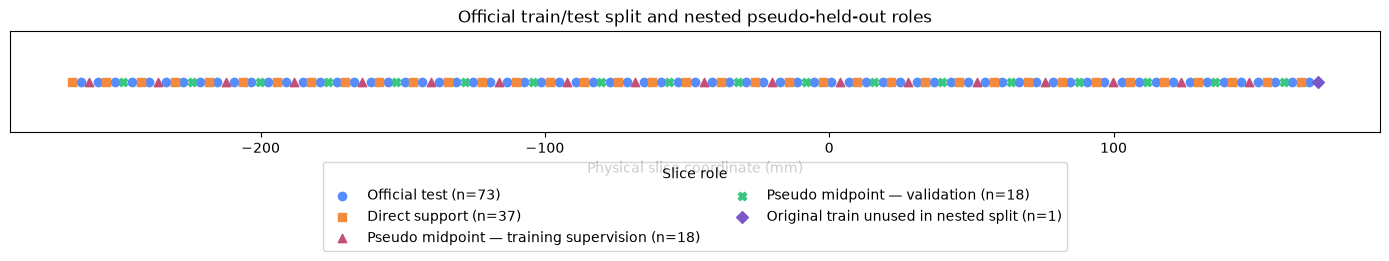

In [18]:
print("Plotting official and nested pseudo-held-out slice roles.")

assigned_nested_indices = set(
    pseudo_support_manifest_df["SliceIndex"]
).union(
    pseudo_target_manifest_df["SliceIndex"]
)

unused_nested_train_df = train_manifest_df.loc[
    ~train_manifest_df["SliceIndex"].isin(
        assigned_nested_indices
    )
].copy()

plt.figure(figsize=(14, 3))

plt.scatter(
    test_manifest_df["SliceCoordinate"],
    np.zeros(len(test_manifest_df)),
    marker="o",
    label=(
        f"Official test "
        f"(n={len(test_manifest_df)})"
    ),
)

plt.scatter(
    pseudo_support_manifest_df["SliceCoordinate"],
    np.zeros(len(pseudo_support_manifest_df)),
    marker="s",
    label=(
        f"Direct support "
        f"(n={len(pseudo_support_manifest_df)})"
    ),
)

plt.scatter(
    pseudo_supervision_manifest_df["SliceCoordinate"],
    np.zeros(len(pseudo_supervision_manifest_df)),
    marker="^",
    label=(
        "Pseudo midpoint — training supervision "
        f"(n={len(pseudo_supervision_manifest_df)})"
    ),
)

plt.scatter(
    pseudo_validation_manifest_df["SliceCoordinate"],
    np.zeros(len(pseudo_validation_manifest_df)),
    marker="X",
    label=(
        "Pseudo midpoint — validation "
        f"(n={len(pseudo_validation_manifest_df)})"
    ),
)

if not unused_nested_train_df.empty:
    plt.scatter(
        unused_nested_train_df["SliceCoordinate"],
        np.zeros(len(unused_nested_train_df)),
        marker="D",
        label=(
            "Original train unused in nested split "
            f"(n={len(unused_nested_train_df)})"
        ),
    )

plt.yticks([])
plt.xlabel("Physical slice coordinate (mm)")
plt.title(
    "Official train/test split and nested pseudo-held-out roles"
)
plt.legend(
    title="Slice role",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=2,
)
plt.tight_layout()
plt.show()

### 14.1 Private pseudo-target training script

The shared repository is not edited. A user-owned copy of `train.py` is
generated under `RESULTS_ROOT/tools`.

Without a pseudo-target environment variable, the script behaves like the
original. When enabled, actual CT midpoints replace the linearly blended
target only on the designated supervision intervals and use `alpha=0.5`.
Other intervals retain the original random-alpha linear IBFR target. The
pseudo-validation intervals never expose their actual CT images to the loss.

The interpolation-loss coefficient is retained unless changed in the
settings cell. The patch validates the expected source markers and stops
when the local MedGS source has changed incompatibly.

In [19]:
print("Creating a private MedGS train.py with actual midpoint targets.")

USER_TOOLS_ROOT = RESULTS_ROOT / "tools"
PATCHED_TRAIN_SCRIPT = (
        USER_TOOLS_ROOT / "train_pseudo_holdout_v2.py"
)


def build_pseudo_train_script() -> Path:
    """Patch a private copy of train.py for actual midpoint targets."""

    source = TRAIN_SCRIPT.read_text(
        encoding="utf-8"
    )

    import_anchor = "from random import randint"
    if import_anchor not in source:
        raise RuntimeError(
            "Cannot patch train.py: import anchor not found."
        )

    source = source.replace(
        import_anchor,
        import_anchor
        + "\nfrom pathlib import Path"
        + "\nfrom PIL import Image"
        + "\nfrom torchvision.transforms.functional "
        + "import pil_to_tensor",
        1,
    )

    helper_code = """
_PSEUDO_ORIGINAL_TARGETS = None
_PSEUDO_MIRROR_TARGETS = None
_PSEUDO_CAMERA_ZERO_IS_ORIGINAL = True


def _load_pseudo_rgb_tensor(path):
    image = Image.open(path).convert("RGB")
    return pil_to_tensor(image).float().cuda() / 255.0


def _configure_pseudo_targets(source_path, gts, camera_mode):
    global _PSEUDO_ORIGINAL_TARGETS
    global _PSEUDO_MIRROR_TARGETS
    global _PSEUDO_CAMERA_ZERO_IS_ORIGINAL

    root_text = os.environ.get(
        "MEDGS_PSEUDO_HOLDOUT_ROOT"
    )

    if not root_text:
        _PSEUDO_ORIGINAL_TARGETS = None
        _PSEUDO_MIRROR_TARGETS = None
        return

    root = Path(root_text)

    _PSEUDO_ORIGINAL_TARGETS = {
        int(path.stem): _load_pseudo_rgb_tensor(path)
        for path in sorted(
            (root / "original").glob("*.png")
        )
    }

    if camera_mode != "mirror":
        _PSEUDO_MIRROR_TARGETS = None
        return

    _PSEUDO_MIRROR_TARGETS = {
        int(path.stem): _load_pseudo_rgb_tensor(path)
        for path in sorted(
            (root / "mirror").glob("*.png")
        )
    }

    support_original = _load_pseudo_rgb_tensor(
        Path(source_path) / "original" / "0000.png"
    )
    support_mirror = _load_pseudo_rgb_tensor(
        Path(source_path) / "mirror" / "0000.png"
    )

    original_error = torch.mean(
        (gts[0] - support_original) ** 2
    )
    mirror_error = torch.mean(
        (gts[0] - support_mirror) ** 2
    )

    _PSEUDO_CAMERA_ZERO_IS_ORIGINAL = bool(
        original_error <= mirror_error
    )

    if set(_PSEUDO_ORIGINAL_TARGETS) != set(
        _PSEUDO_MIRROR_TARGETS
    ):
        raise RuntimeError(
            "Pseudo original and mirror pair IDs differ."
        )


def _pseudo_or_linear_target(
    A,
    B,
    alpha,
    camera_index,
    overlap,
    camera_name,
    camera_mode,
):
    if _PSEUDO_ORIGINAL_TARGETS is None:
        return interpolate(A, B, alpha), alpha

    lower_camera_index = (
        camera_index - overlap
        if camera_name == "camera_prev"
        else camera_index
    )
    pair_index = lower_camera_index // overlap

    if camera_mode == "mirror":
        even_camera = (
            lower_camera_index % overlap == 0
        )
        use_original = (
            even_camera
            == _PSEUDO_CAMERA_ZERO_IS_ORIGINAL
        )
        target_list = (
            _PSEUDO_ORIGINAL_TARGETS
            if use_original
            else _PSEUDO_MIRROR_TARGETS
        )
    else:
        target_list = _PSEUDO_ORIGINAL_TARGETS

    if pair_index not in target_list:
        return interpolate(A, B, alpha), alpha

    return target_list[pair_index], 0.5


def _interpolation_loss_weight():
    return float(
        os.environ.get(
            "MEDGS_PSEUDO_HOLDOUT_WEIGHT",
            "0.5",
        )
    )

"""

    training_anchor = "\ndef training("
    if training_anchor not in source:
        raise RuntimeError(
            "Cannot patch train.py: training() not found."
        )

    source = source.replace(
        training_anchor,
        "\n"
        + helper_code
        + "\ndef training(",
        1,
    )

    overlap_pattern = re.compile(
        r'^(?P<indent>[ \t]*)'
        r'prev_next_overlap\s*=\s*2\s+'
        r'if\s+dataset\.camera\s*==\s*"mirror"\s+'
        r'else\s+1\s*$',
        re.MULTILINE,
    )
    overlap_match = overlap_pattern.search(
        source
    )

    if overlap_match is None:
        raise RuntimeError(
            "Cannot patch train.py: camera overlap "
            "marker not found."
        )

    indent = overlap_match.group("indent")
    replacement = (
            overlap_match.group(0)
            + "\n"
            + indent
            + "_configure_pseudo_targets("
            + "dataset.source_path, gts, dataset.camera)"
    )

    source = (
            source[:overlap_match.start()]
            + replacement
            + source[overlap_match.end():]
    )

    training_start = source.index(
        "def training("
    )
    training_end = source.find(
        "\ndef training_",
        training_start + 1,
    )
    if training_end == -1:
        training_end = len(source)

    training_block = source[
        training_start:training_end
    ]

    interpolation_pattern = re.compile(
        r"interpolated_img\s*=\s*"
        r"interpolate\(A,\s*B,\s*alpha\)"
    )

    if len(
            interpolation_pattern.findall(
                training_block
            )
    ) != 2:
        raise RuntimeError(
            "Expected exactly two image interpolation "
            "targets in training()."
        )

    training_block = (
        interpolation_pattern.sub(
            "interpolated_img, alpha = "
            "_pseudo_or_linear_target("
            "A, B, alpha, idx, "
            "prev_next_overlap, name, "
            "dataset.camera)",
            training_block,
            count=2,
        )
    )

    loss_pattern = re.compile(
        r"0\.5\s*\*\s*Ll1_inter"
    )
    if loss_pattern.search(
            training_block
    ) is None:
        raise RuntimeError(
            "Cannot patch train.py: interpolation "
            "loss term not found."
        )

    training_block = loss_pattern.sub(
        "_interpolation_loss_weight() "
        "* Ll1_inter",
        training_block,
        count=1,
    )

    source = (
            source[:training_start]
            + training_block
            + source[training_end:]
    )

    USER_TOOLS_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )
    PATCHED_TRAIN_SCRIPT.write_text(
        source,
        encoding="utf-8",
    )
    compile(
        source,
        str(PATCHED_TRAIN_SCRIPT),
        "exec",
    )

    return PATCHED_TRAIN_SCRIPT


build_pseudo_train_script()

print(f"Original script: {TRAIN_SCRIPT}")
print(f"Patched script:  {PATCHED_TRAIN_SCRIPT}")

Creating a private MedGS train.py with actual midpoint targets.
Original script: /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/repo/MedGS/train.py
Patched script:  /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/tools/train_pseudo_holdout_v2.py


### 14.2 Ablation configuration

All pseudo-held-out rows use the same direct support frames and the same
pseudo-validation targets, so every structural variant can be compared directly
with the common nested baseline B0. Only one factor differs in B1–B4.

The original official-test run above remains a separate reference and must not
be treated as directly comparable with the nested pseudo-held-out rows.

The “DICOM geometry” switch removes the synthetic mirror and uses one fixed view
after verifying regular physical slice spacing.

In [20]:
print("Defining independent ablations against one nested baseline.")

ABLATION_ITERATIONS = 30_000
ABLATION_BATCH_SIZE = 3
ABLATION_RENDER_INTERPOLATION = 2
PSEUDO_HOLDOUT_WEIGHT = 0.5

RUN_ABLATIONS = False
REUSE_COMPLETED_RUNS = False

ABLATION_SPECS = [
    {
        "run_name": (
            "ablation_b0_nested_baseline_v3"
        ),
        "scope": "pseudo_holdout",
        "use_pseudo_holdout_loss": False,
        "use_dicom_geometry": False,
        "poly_degree": 2,
        "use_multiwindow_rgb": False,
        "description": (
            "B0: nested baseline"
        ),
    },
    {
        "run_name": (
            "ablation_b1_pseudo_loss_only_v3"
        ),
        "scope": "pseudo_holdout",
        "use_pseudo_holdout_loss": True,
        "use_dicom_geometry": False,
        "poly_degree": 2,
        "use_multiwindow_rgb": False,
        "description": (
            "B1: actual midpoint supervision only"
        ),
    },
    {
        "run_name": (
            "ablation_b2_dicom_single_view_only_v3"
        ),
        "scope": "pseudo_holdout",
        "use_pseudo_holdout_loss": False,
        "use_dicom_geometry": True,
        "poly_degree": 2,
        "use_multiwindow_rgb": False,
        "description": (
            "B2: DICOM-ordered single view only"
        ),
    },
    {
        "run_name": (
            "ablation_b3_poly1_only_v3"
        ),
        "scope": "pseudo_holdout",
        "use_pseudo_holdout_loss": False,
        "use_dicom_geometry": False,
        "poly_degree": 1,
        "use_multiwindow_rgb": False,
        "description": (
            "B3: polynomial degree 1 only"
        ),
    },
    {
        "run_name": (
            "ablation_b4_multiwindow_rgb_only_v3"
        ),
        "scope": "pseudo_holdout",
        "use_pseudo_holdout_loss": False,
        "use_dicom_geometry": False,
        "poly_degree": 2,
        "use_multiwindow_rgb": True,
        "description": (
            "B4: three-window CT encoding only"
        ),
    },
]

display(pd.DataFrame(ABLATION_SPECS))

Defining independent ablations against one nested baseline.


,run_name,scope,use_pseudo_holdout_loss,use_dicom_geometry,poly_degree,use_multiwindow_rgb,description
0,ablation_b0_nested_baseline_v3,pseudo_holdout,False,False,2,False,B0: nested baseline
1,ablation_b1_pseudo_loss_only_v3,pseudo_holdout,True,False,2,False,B1: actual midpoint supervision only
2,ablation_b2_dicom_single_view_only_v3,pseudo_holdout,False,True,2,False,B2: DICOM-ordered single view only
3,ablation_b3_poly1_only_v3,pseudo_holdout,False,False,1,False,B3: polynomial degree 1 only
4,ablation_b4_multiwindow_rgb_only_v3,pseudo_holdout,False,False,2,True,B4: three-window CT encoding only


### 14.3 Reusable ablation runner

Each run writes a separate dataset, model, renders, manifests, per-slice
metrics, and concise run record.

The first RGB channel always contains the original HU window, so
`Primary_PSNR` and `Primary_SSIM` remain directly comparable across grayscale
and multi-window variants.

The multi-window encoding is:

- channel 0: the original experiment window;
- channel 1: soft tissue `[-160, 240] HU`;
- channel 2: broad bone/high-density `[-500, 1500] HU`.

LPIPS is also reported, but its absolute values should be interpreted
cautiously for the pseudo-color multi-window representation because AlexNet
was trained on natural RGB images.

In [21]:
print("Defining reusable ablation preparation and metric functions.")

ABLATION_ROOT = (
        EXPERIMENTS_ROOT
        / CONFIG_NAME
        / SELECTED_CASE_NAME
)


def encode_hu_rgb(
        image_hu: np.ndarray,
        use_multiwindow_rgb: bool,
) -> np.ndarray:
    """Encode CT as repeated grayscale or three HU windows."""

    primary = window_hu(
        image_hu,
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )

    if not use_multiwindow_rgb:
        return np.repeat(
            primary[..., None],
            3,
            axis=2,
        )

    soft = window_hu(
        image_hu,
        -160.0,
        240.0,
    )
    bone = window_hu(
        image_hu,
        -500.0,
        1500.0,
    )

    return np.stack(
        [primary, soft, bone],
        axis=-1,
    )


def load_png_rgb(path: Path) -> np.ndarray:
    """Load one PNG as normalized RGB data."""

    return np.asarray(
        Image.open(path).convert("RGB"),
        dtype=np.float32,
    ) / 255.0


def lpips_rgb(
        reference: np.ndarray,
        prediction: np.ndarray,
) -> float:
    """Compute LPIPS for normalized RGB arrays."""

    reference_tensor = (
            torch.from_numpy(reference)
            .permute(2, 0, 1)
            .unsqueeze(0)
            .float()
            .cuda()
            * 2.0
            - 1.0
    )
    prediction_tensor = (
            torch.from_numpy(prediction)
            .permute(2, 0, 1)
            .unsqueeze(0)
            .float()
            .cuda()
            * 2.0
            - 1.0
    )

    with torch.no_grad():
        return float(
            lpips_model(
                reference_tensor,
                prediction_tensor,
            ).item()
        )


def rgb_metrics(
        reference: np.ndarray,
        prediction: np.ndarray,
) -> dict[str, float]:
    """Compute primary-window, RGB, and LPIPS metrics."""

    return {
        "Primary_PSNR": (
            peak_signal_noise_ratio(
                reference[..., 0],
                prediction[..., 0],
                data_range=1.0,
            )
        ),
        "Primary_SSIM": (
            structural_similarity(
                reference[..., 0],
                prediction[..., 0],
                data_range=1.0,
            )
        ),
        "RGB_PSNR": peak_signal_noise_ratio(
            reference,
            prediction,
            data_range=1.0,
        ),
        "RGB_SSIM": structural_similarity(
            reference,
            prediction,
            data_range=1.0,
            channel_axis=-1,
        ),
        "LPIPS": lpips_rgb(
            reference,
            prediction,
        ),
    }


def ablation_paths(
        run_name: str,
) -> dict[str, Path]:
    """Return all paths for one ablation run."""

    root = ABLATION_ROOT / run_name
    model = root / "model"

    return {
        "root": root,
        "dataset": root / "dataset",
        "original": (
                root / "dataset" / "original"
        ),
        "mirror": (
                root / "dataset" / "mirror"
        ),
        "pseudo": (
                root
                / "dataset"
                / "pseudo_targets"
        ),
        "model": model,
        "render": model / "render_img",
        "support": (
                root / "support_manifest.csv"
        ),
        "target": (
                root / "target_manifest.csv"
        ),
        "frames": root / "frame_manifest.csv",
        "train_metrics": (
                root / "train_metrics.csv"
        ),
        "metrics": root / "metrics.csv",
        "reconstruction": (
                root / "reconstruction_manifest.csv"
        ),
        "summary": root / "summary.json",
        "run_record": root / "run.json",
        "geometry": (
                root / "slice_geometry.json"
        ),
    }


def manifests_for_scope(
        scope: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return support and target frames for one scope."""

    if scope == "pseudo_holdout":
        return (
            pseudo_support_manifest_df.copy(),
            pseudo_validation_manifest_df.copy(),
        )

    if scope == "official_test":
        return (
            train_manifest_df.copy(),
            test_manifest_df.copy(),
        )

    raise ValueError(
        f"Unknown scope: {scope}"
    )


def detect_ablation_render_layout(
        render_root: Path,
        frame_df: pd.DataFrame,
) -> tuple[int, int]:
    """Detect rendered views per support frame."""

    base_files = sorted(
        render_root.glob("*_0.png")
    )
    frame_count = len(frame_df)

    if len(base_files) == frame_count:
        return 1, 0

    if len(base_files) != 2 * frame_count:
        raise RuntimeError(
            f"Unexpected render count: "
            f"{len(base_files)}."
        )

    reference = load_png_rgb(
        Path(
            frame_df.iloc[0][
                "OriginalPNG"
            ]
        )
    )
    first = load_png_rgb(
        render_root / "00000_0.png"
    )
    second = load_png_rgb(
        render_root / "00001_0.png"
    )

    return (
        2,
        int(
            np.mean(
                (second - reference) ** 2
            )
            < np.mean(
                (first - reference) ** 2
            )
        ),
    )

Defining reusable ablation preparation and metric functions.


In [22]:
print("Defining MedGS dataset preparation for each ablation.")


def prepare_ablation_dataset(
        spec: dict,
        paths: dict[str, Path],
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
]:
    """Write support images and optional actual midpoint targets."""

    support_df, target_df = manifests_for_scope(
        spec["scope"]
    )
    support_df = (
        support_df
        .sort_values("SliceCoordinate")
        .reset_index(drop=True)
    )
    target_df = (
        target_df
        .sort_values("SliceCoordinate")
        .reset_index(drop=True)
    )

    if (
            spec["use_dicom_geometry"]
            and spec["scope"] == "official_test"
    ):
        required_coordinates = set(
            target_df[
                "LowerTrainCoordinate"
            ].astype(float)
        ) | set(
            target_df[
                "UpperTrainCoordinate"
            ].astype(float)
        )
        support_df = (
            support_df.loc[
                support_df[
                    "SliceCoordinate"
                ].astype(float).isin(
                    required_coordinates
                )
            ]
            .sort_values("SliceCoordinate")
            .reset_index(drop=True)
        )

    if spec["use_dicom_geometry"]:
        coordinates = support_df[
            "SliceCoordinate"
        ].to_numpy(dtype=float)
        spacing = np.diff(coordinates)

        if not np.allclose(
                spacing,
                np.median(spacing),
                rtol=0.0,
                atol=1e-4,
        ):
            raise ValueError(
                "DICOM single-view mode requires "
                "regular physical slice spacing."
            )

    shutil.rmtree(
        paths["dataset"],
        ignore_errors=True,
    )
    paths["original"].mkdir(parents=True)
    paths["mirror"].mkdir(parents=True)

    frame_rows = []

    for frame_index, row in support_df.iterrows():
        encoded = encode_hu_rgb(
            read_hu_image(Path(row["Path"])),
            spec["use_multiwindow_rgb"],
        )
        encoded_uint8 = np.round(
            np.clip(encoded, 0.0, 1.0)
            * 255.0
        ).astype(np.uint8)

        filename = f"{frame_index:04d}.png"
        original_path = (
                paths["original"] / filename
        )
        mirror_path = (
                paths["mirror"] / filename
        )

        Image.fromarray(
            encoded_uint8
        ).save(original_path)
        Image.fromarray(
            np.fliplr(encoded_uint8)
        ).save(mirror_path)

        frame_rows.append(
            {
                "FrameIndex": frame_index,
                "SliceIndex": int(
                    row["SliceIndex"]
                ),
                "SliceCoordinate": float(
                    row["SliceCoordinate"]
                ),
                "DICOMRelativePath": row[
                    "DICOMRelativePath"
                ],
                "Path": row["Path"],
                "OriginalPNG": str(
                    original_path
                ),
            }
        )

    frame_df = pd.DataFrame(frame_rows)

    if spec["use_pseudo_holdout_loss"]:
        pseudo_original = (
                paths["pseudo"] / "original"
        )
        pseudo_mirror = (
                paths["pseudo"] / "mirror"
        )
        pseudo_original.mkdir(parents=True)
        pseudo_mirror.mkdir(parents=True)

        for _, row in (
                pseudo_supervision_manifest_df.iterrows()
        ):
            pair_index = int(row["PairIndex"])
            encoded = encode_hu_rgb(
                read_hu_image(Path(row["Path"])),
                spec["use_multiwindow_rgb"],
            )
            encoded_uint8 = np.round(
                np.clip(encoded, 0.0, 1.0)
                * 255.0
            ).astype(np.uint8)
            filename = f"{pair_index:04d}.png"

            Image.fromarray(
                encoded_uint8
            ).save(
                pseudo_original / filename
            )
            Image.fromarray(
                np.fliplr(encoded_uint8)
            ).save(
                pseudo_mirror / filename
            )

    paths["root"].mkdir(
        parents=True,
        exist_ok=True,
    )
    support_df.to_csv(
        paths["support"],
        index=False,
    )
    target_df.to_csv(
        paths["target"],
        index=False,
    )
    frame_df.to_csv(
        paths["frames"],
        index=False,
    )

    first_dicom = pydicom.dcmread(
        str(Path(support_df.iloc[0]["Path"])),
        stop_before_pixels=True,
        force=True,
    )
    coordinates = support_df[
        "SliceCoordinate"
    ].to_numpy(dtype=float)

    geometry = {
        "ordered_by": "SliceCoordinate",
        "slice_coordinates_mm": (
            coordinates.tolist()
        ),
        "image_orientation_patient": [
            float(value)
            for value in (
                first_dicom.ImageOrientationPatient
            )
        ],
        "pixel_spacing_mm": [
            float(value)
            for value in first_dicom.PixelSpacing
        ],
        "slice_spacing_mm": float(
            np.median(np.diff(coordinates))
        ),
        "camera": (
            "one"
            if spec["use_dicom_geometry"]
            else "mirror"
        ),
        "note": (
            "Uniform frame time is an affine "
            "mapping of physical z for this "
            "regular stack."
        ),
    }
    paths["geometry"].write_text(
        json.dumps(geometry, indent=2)
        + "\n",
        encoding="utf-8",
    )

    return support_df, target_df, frame_df

Defining MedGS dataset preparation for each ablation.


In [23]:
print("Defining the reusable MedGS ablation execution function.")


def run_ablation(spec: dict) -> dict:
    """Train, render, evaluate, and save one ablation run."""

    paths = ablation_paths(spec["run_name"])

    if (
            REUSE_COMPLETED_RUNS
            and paths["summary"].is_file()
    ):
        print(
            f"Reusing completed run: "
            f"{spec['run_name']}"
        )
        return json.loads(
            paths["summary"].read_text(
                encoding="utf-8"
            )
        )

    support_df, target_df, frame_df = (
        prepare_ablation_dataset(
            spec,
            paths,
        )
    )

    camera = (
        "one"
        if spec["use_dicom_geometry"]
        else "mirror"
    )
    training_script = (
        PATCHED_TRAIN_SCRIPT
        if spec["use_pseudo_holdout_loss"]
        else TRAIN_SCRIPT
    )

    train_command = [
        sys.executable,
        str(training_script),
        "-s",
        str(paths["dataset"]),
        "-m",
        str(paths["model"]),
        "--pipeline",
        "img",
        "--iterations",
        str(ABLATION_ITERATIONS),
        "--poly_degree",
        str(spec["poly_degree"]),
        "--batch_size",
        str(ABLATION_BATCH_SIZE),
        "--camera",
        camera,
        "--test_iterations",
        str(ABLATION_ITERATIONS),
        "--save_iterations",
        str(ABLATION_ITERATIONS),
        "--checkpoint_iterations",
        str(ABLATION_ITERATIONS),
    ]

    environment = os.environ.copy()
    environment["PYTHONPATH"] = (
            str(MEDGS_REPOSITORY)
            + os.pathsep
            + environment.get(
        "PYTHONPATH",
        "",
    )
    )

    if spec["use_pseudo_holdout_loss"]:
        environment[
            "MEDGS_PSEUDO_HOLDOUT_ROOT"
        ] = str(paths["pseudo"])
        environment[
            "MEDGS_PSEUDO_HOLDOUT_WEIGHT"
        ] = str(PSEUDO_HOLDOUT_WEIGHT)

    if paths["model"].exists():
        if not REUSE_COMPLETED_RUNS:
            raise FileExistsError(
                f"Model already exists: "
                f"{paths['model']}"
            )
        print(
            f"Reusing model: "
            f"{paths['model']}"
        )
    else:
        print(
            "Training command:\n"
            + " ".join(
                shlex.quote(part)
                for part in train_command
            )
        )
        subprocess.run(
            train_command,
            cwd=MEDGS_REPOSITORY,
            env=environment,
            check=True,
        )

    render_command = [
        sys.executable,
        str(RENDER_SCRIPT),
        "--model_path",
        str(paths["model"]),
        "--iteration",
        "-1",
        "--interp",
        str(
            ABLATION_RENDER_INTERPOLATION
        ),
        "--pipeline",
        "img",
        "--camera",
        camera,
        "--poly_degree",
        str(spec["poly_degree"]),
        "--chunks",
        "1",
    ]

    existing_renders = (
            paths["render"].is_dir()
            and bool(
        list(
            paths["render"].glob(
                "*.png"
            )
        )
    )
    )

    if (
            existing_renders
            and REUSE_COMPLETED_RUNS
    ):
        print(
            f"Reusing renders: "
            f"{paths['render']}"
        )
    else:
        shutil.rmtree(
            paths["render"],
            ignore_errors=True,
        )
        print(
            "Rendering command:\n"
            + " ".join(
                shlex.quote(part)
                for part in render_command
            )
        )
        subprocess.run(
            render_command,
            cwd=MEDGS_REPOSITORY,
            check=True,
        )

    camera_stride, camera_offset = (
        detect_ablation_render_layout(
            paths["render"],
            frame_df,
        )
    )

    coordinate_to_frame = dict(
        zip(
            frame_df["SliceCoordinate"],
            frame_df["FrameIndex"],
        )
    )
    support_by_coordinate = (
        support_df.set_index(
            "SliceCoordinate"
        )
    )

    train_rows = []

    for _, frame in frame_df.iterrows():
        frame_index = int(
            frame["FrameIndex"]
        )
        view_index = (
                camera_offset
                + camera_stride * frame_index
        )
        render_path = (
                paths["render"]
                / f"{view_index:05d}_0.png"
        )

        reference = encode_hu_rgb(
            read_hu_image(
                Path(frame["Path"])
            ),
            spec["use_multiwindow_rgb"],
        )
        prediction = load_png_rgb(
            render_path
        )
        metrics = rgb_metrics(
            reference,
            prediction,
        )

        train_rows.append(
            {
                "FrameIndex": frame_index,
                "SliceIndex": int(
                    frame["SliceIndex"]
                ),
                "SliceCoordinate": float(
                    frame["SliceCoordinate"]
                ),
                **metrics,
                "RenderPath": str(
                    render_path
                ),
            }
        )

    ablation_train_metrics_df = (
        pd.DataFrame(train_rows)
    )

    reconstruction_rows = []
    interpolation_rows = []

    for _, target in target_df.iterrows():
        lower_coordinate = float(
            target[
                "LowerTrainCoordinate"
            ]
        )
        upper_coordinate = float(
            target[
                "UpperTrainCoordinate"
            ]
        )
        target_coordinate = float(
            target["SliceCoordinate"]
        )

        expected_midpoint = 0.5 * (
                lower_coordinate
                + upper_coordinate
        )
        if not np.isclose(
                target_coordinate,
                expected_midpoint,
        ):
            raise ValueError(
                "Target is not the physical "
                "midpoint of its support pair."
            )

        lower_frame = int(
            coordinate_to_frame[
                lower_coordinate
            ]
        )
        upper_frame = int(
            coordinate_to_frame[
                upper_coordinate
            ]
        )
        view_index = (
                camera_offset
                + camera_stride * lower_frame
        )
        reconstruction_path = (
                paths["render"]
                / f"{view_index:05d}_1.png"
        )

        lower_path = (
            support_by_coordinate.loc[
                lower_coordinate,
                "Path",
            ]
        )
        upper_path = (
            support_by_coordinate.loc[
                upper_coordinate,
                "Path",
            ]
        )

        reference = encode_hu_rgb(
            read_hu_image(
                Path(target["Path"])
            ),
            spec["use_multiwindow_rgb"],
        )
        prediction = load_png_rgb(
            reconstruction_path
        )
        lower = encode_hu_rgb(
            read_hu_image(
                Path(lower_path)
            ),
            spec["use_multiwindow_rgb"],
        )
        upper = encode_hu_rgb(
            read_hu_image(
                Path(upper_path)
            ),
            spec["use_multiwindow_rgb"],
        )
        linear = 0.5 * (
                lower + upper
        )

        medgs_metrics = rgb_metrics(
            reference,
            prediction,
        )
        linear_metrics = rgb_metrics(
            reference,
            linear,
        )

        reconstruction_rows.append(
            {
                "SliceIndex": int(
                    target["SliceIndex"]
                ),
                "SliceCoordinate": (
                    target_coordinate
                ),
                "PairIndex": target.get(
                    "PairIndex",
                    np.nan,
                ),
                "PseudoRole": target.get(
                    "PseudoRole",
                    "",
                ),
                "GroundTruthPath": (
                    target["Path"]
                ),
                "LowerTrainFrame": (
                    lower_frame
                ),
                "UpperTrainFrame": (
                    upper_frame
                ),
                "LowerTrainPath": (
                    lower_path
                ),
                "UpperTrainPath": (
                    upper_path
                ),
                "ReconstructionPath": str(
                    reconstruction_path
                ),
            }
        )

        interpolation_rows.append(
            {
                "SliceIndex": int(
                    target["SliceIndex"]
                ),
                "SliceCoordinate": (
                    target_coordinate
                ),
                "PairIndex": target.get(
                    "PairIndex",
                    np.nan,
                ),
                "PseudoRole": target.get(
                    "PseudoRole",
                    "",
                ),
                **{
                    f"MedGS_{key}": value
                    for key, value
                    in medgs_metrics.items()
                },
                **{
                    f"Linear_{key}": value
                    for key, value
                    in linear_metrics.items()
                },
                "ReconstructionPath": str(
                    reconstruction_path
                ),
                "GroundTruthPath": (
                    target["Path"]
                ),
            }
        )

    reconstruction_df = pd.DataFrame(
        reconstruction_rows
    )
    ablation_metrics_df = pd.DataFrame(
        interpolation_rows
    )

    ablation_train_metrics_df.to_csv(
        paths["train_metrics"],
        index=False,
    )
    reconstruction_df.to_csv(
        paths["reconstruction"],
        index=False,
    )
    ablation_metrics_df.to_csv(
        paths["metrics"],
        index=False,
    )

    summary = {
        "run_name": spec["run_name"],
        "description": spec["description"],
        "scope": spec["scope"],
        "use_pseudo_holdout_loss": (
            spec[
                "use_pseudo_holdout_loss"
            ]
        ),
        "use_dicom_geometry": (
            spec["use_dicom_geometry"]
        ),
        "camera": camera,
        "poly_degree": (
            spec["poly_degree"]
        ),
        "use_multiwindow_rgb": (
            spec[
                "use_multiwindow_rgb"
            ]
        ),
        "iterations": (
            ABLATION_ITERATIONS
        ),
        "batch_size": (
            ABLATION_BATCH_SIZE
        ),
        "support_slices": len(
            support_df
        ),
        "pseudo_supervision_slices": (
            len(pseudo_supervision_manifest_df)
            if spec["use_pseudo_holdout_loss"]
            else 0
        ),
        "target_slices": len(
            target_df
        ),
        "train_primary_psnr": float(
            ablation_train_metrics_df[
                "Primary_PSNR"
            ].mean()
        ),
        "train_primary_ssim": float(
            ablation_train_metrics_df[
                "Primary_SSIM"
            ].mean()
        ),
        "train_lpips": float(
            ablation_train_metrics_df[
                "LPIPS"
            ].mean()
        ),
        "medgs_primary_psnr": float(
            ablation_metrics_df[
                "MedGS_Primary_PSNR"
            ].mean()
        ),
        "medgs_primary_ssim": float(
            ablation_metrics_df[
                "MedGS_Primary_SSIM"
            ].mean()
        ),
        "medgs_lpips": float(
            ablation_metrics_df[
                "MedGS_LPIPS"
            ].mean()
        ),
        "linear_primary_psnr": float(
            ablation_metrics_df[
                "Linear_Primary_PSNR"
            ].mean()
        ),
        "linear_primary_ssim": float(
            ablation_metrics_df[
                "Linear_Primary_SSIM"
            ].mean()
        ),
        "linear_lpips": float(
            ablation_metrics_df[
                "Linear_LPIPS"
            ].mean()
        ),
        "run_root": str(
            paths["root"]
        ),
    }

    run_record = {
        **summary,
        "config_name": CONFIG_NAME,
        "case_name": SELECTED_CASE_NAME,
        "support_manifest": str(
            paths["support"]
        ),
        "target_manifest": str(
            paths["target"]
        ),
        "frame_manifest": str(
            paths["frames"]
        ),
        "train_metrics": str(
            paths["train_metrics"]
        ),
        "reconstruction_manifest": str(
            paths["reconstruction"]
        ),
        "metrics": str(
            paths["metrics"]
        ),
        "geometry": str(
            paths["geometry"]
        ),
        "model_root": str(
            paths["model"]
        ),
        "render_root": str(
            paths["render"]
        ),
        "training_command": (
            train_command
        ),
        "render_command": (
            render_command
        ),
    }

    paths["summary"].write_text(
        json.dumps(
            summary,
            indent=2,
        )
        + "\n",
        encoding="utf-8",
    )
    paths["run_record"].write_text(
        json.dumps(
            run_record,
            indent=2,
        )
        + "\n",
        encoding="utf-8",
    )

    return summary

Defining the reusable MedGS ablation execution function.


### 14.4 Run and collect ablations

The combined table contains the completed v4 official-test baseline and five
nested pseudo-held-out runs: one common baseline B0 and four independent
one-factor variants B1–B4. Compare rows directly only within the same `scope`.

Higher PSNR/SSIM and lower LPIPS are better. Training metrics diagnose
support-image fitting; midpoint metrics evaluate interpolation.

Five new runs at 30,000 iterations are expensive. Completed runs are reused
when their `summary.json` exists.

In [24]:
print("Running or loading the configured ablation sequence.")

ablation_rows = []

if RUN_ABLATIONS:
    for index, spec in enumerate(
            ABLATION_SPECS,
            start=1,
    ):
        print(
            f"\n[{index}/"
            f"{len(ABLATION_SPECS)}] "
            f"{spec['run_name']}"
        )
        ablation_rows.append(
            run_ablation(spec)
        )
else:
    for spec in ABLATION_SPECS:
        summary_path = (
            ablation_paths(
                spec["run_name"]
            )["summary"]
        )
        if summary_path.is_file():
            ablation_rows.append(
                json.loads(
                    summary_path.read_text(
                        encoding="utf-8"
                    )
                )
            )

ablation_results_df = pd.DataFrame(
    ablation_rows
)

baseline_medgs = (
    metrics_summary_df.loc[
        metrics_summary_df["Method"]
        == "MedGS"
        ]
    .iloc[0]
)
baseline_linear = (
    metrics_summary_df.loc[
        metrics_summary_df["Method"]
        == "Linear interpolation"
        ]
    .iloc[0]
)
baseline_train = (
    train_metrics_summary_df.iloc[0]
)

official_baseline_df = pd.DataFrame(
    [
        {
            "run_name": RUN_NAME,
            "description": (
                "v4 official-test baseline"
            ),
            "scope": "official_test",
            "use_pseudo_holdout_loss": False,
            "use_dicom_geometry": False,
            "camera": CAMERA,
            "poly_degree": POLY_DEGREE,
            "use_multiwindow_rgb": False,
            "iterations": ITERATIONS,
            "batch_size": BATCH_SIZE,
            "support_slices": len(
                train_manifest_df
            ),
            "target_slices": len(
                test_manifest_df
            ),
            "train_primary_psnr": float(
                baseline_train["PSNR"]
            ),
            "train_primary_ssim": float(
                baseline_train["SSIM"]
            ),
            "train_lpips": float(
                baseline_train["LPIPS"]
            ),
            "medgs_primary_psnr": float(
                baseline_medgs["PSNR"]
            ),
            "medgs_primary_ssim": float(
                baseline_medgs["SSIM"]
            ),
            "medgs_lpips": float(
                baseline_medgs["LPIPS"]
            ),
            "linear_primary_psnr": float(
                baseline_linear["PSNR"]
            ),
            "linear_primary_ssim": float(
                baseline_linear["SSIM"]
            ),
            "linear_lpips": float(
                baseline_linear["LPIPS"]
            ),
            "run_root": str(RUN_ROOT),
        }
    ]
)

all_results_df = pd.concat(
    [
        official_baseline_df,
        ablation_results_df,
    ],
    ignore_index=True,
    sort=False,
)

ABLATION_RESULTS_PATH = (
        ABLATION_ROOT
        / "ablation_results_v3.csv"
)
all_results_df.to_csv(
    ABLATION_RESULTS_PATH,
    index=False,
)

print(
    f"Combined results saved to: "
    f"{ABLATION_RESULTS_PATH}"
)
print(
    "Compare metric values directly only within "
    "the same evaluation scope."
)

display(
    all_results_df[
        [
            "run_name",
            "scope",
            "description",
            "use_pseudo_holdout_loss",
            "use_dicom_geometry",
            "poly_degree",
            "use_multiwindow_rgb",
            "train_primary_psnr",
            "train_primary_ssim",
            "train_lpips",
            "medgs_primary_psnr",
            "medgs_primary_ssim",
            "medgs_lpips",
            "linear_primary_psnr",
            "linear_primary_ssim",
            "linear_lpips",
        ]
    ]
)

Running or loading the configured ablation sequence.
Combined results saved to: /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/ablation_results_v3.csv
Compare metric values directly only within the same evaluation scope.


,run_name,scope,description,use_pseudo_holdout_loss,use_dicom_geometry,poly_degree,use_multiwindow_rgb,train_primary_psnr,train_primary_ssim,train_lpips,medgs_primary_psnr,medgs_primary_ssim,medgs_lpips,linear_primary_psnr,linear_primary_ssim,linear_lpips
0,medgs_img_poly2_30000_v4,official_test,v4 official-test baseline,False,False,2,False,40.452961,0.963683,0.048926,30.605865,0.797267,0.098635,30.343046,0.814462,0.065428
1,ablation_b0_nested_baseline_v3,pseudo_holdout,B0: nested baseline,False,False,2,False,43.019039,0.977596,0.021703,26.731786,0.730177,0.119527,26.109918,0.728790,0.095665
2,ablation_b1_pseudo_loss_only_v3,pseudo_holdout,B1: actual midpoint supervision only,True,False,2,False,42.742579,0.977572,0.023009,26.951623,0.733333,0.122386,26.109918,0.728790,0.095665
3,ablation_b2_dicom_single_view_only_v3,pseudo_holdout,B2: DICOM-ordered single view only,False,True,2,False,39.521059,0.957139,0.045036,27.263490,0.736889,0.140175,26.109918,0.728790,0.095665
4,ablation_b3_poly1_only_v3,pseudo_holdout,B3: polynomial degree 1 only,False,False,1,False,42.027829,0.975910,0.027365,26.628802,0.731877,0.125317,26.109918,0.728790,0.095665
5,ablation_b4_multiwindow_rgb_only_v3,pseudo_holdout,B4: three-window CT encoding only,False,False,2,True,40.118809,0.946423,0.016737,27.032647,0.753300,0.106046,26.109918,0.728790,0.086645


In [25]:
print("Calculating each one-factor effect relative to common baseline B0.")

ablation_comparison_df = (
    ablation_results_df.copy()
)

if not ablation_comparison_df.empty:
    reference = (
        ablation_comparison_df.iloc[0]
    )

    ablation_comparison_df[
        "Delta_PSNR"
    ] = (
            ablation_comparison_df[
                "medgs_primary_psnr"
            ]
            - reference[
                "medgs_primary_psnr"
            ]
    )
    ablation_comparison_df[
        "Delta_SSIM"
    ] = (
            ablation_comparison_df[
                "medgs_primary_ssim"
            ]
            - reference[
                "medgs_primary_ssim"
            ]
    )
    ablation_comparison_df[
        "Delta_LPIPS"
    ] = (
            ablation_comparison_df[
                "medgs_lpips"
            ]
            - reference[
                "medgs_lpips"
            ]
    )

display(
    ablation_comparison_df[
        [
            "run_name",
            "description",
            "medgs_primary_psnr",
            "medgs_primary_ssim",
            "medgs_lpips",
            "Delta_PSNR",
            "Delta_SSIM",
            "Delta_LPIPS",
        ]
    ]
)

Calculating each one-factor effect relative to common baseline B0.


,run_name,description,medgs_primary_psnr,medgs_primary_ssim,medgs_lpips,Delta_PSNR,Delta_SSIM,Delta_LPIPS
0,ablation_b0_nested_baseline_v3,B0: nested baseline,26.731786,0.730177,0.119527,0.000000,0.000000,0.000000
1,ablation_b1_pseudo_loss_only_v3,B1: actual midpoint supervision only,26.951623,0.733333,0.122386,0.219837,0.003156,0.002859
2,ablation_b2_dicom_single_view_only_v3,B2: DICOM-ordered single view only,27.263490,0.736889,0.140175,0.531704,0.006713,0.020648
3,ablation_b3_poly1_only_v3,B3: polynomial degree 1 only,26.628802,0.731877,0.125317,-0.102984,0.001700,0.005790
4,ablation_b4_multiwindow_rgb_only_v3,B4: three-window CT encoding only,27.032647,0.753300,0.106046,0.300861,0.023124,-0.013481


In [27]:
# print("Cancelling the current Slurm allocation.")
#
# job_id = os.environ["SLURM_JOB_ID"]
#
# print(
#     f"Cancelling Slurm job {job_id}. "
#     "The Jupyter connection will close immediately."
# )
#
# subprocess.run(
#     ["scancel", job_id],
#     check=True,
# )

Cancelling the current Slurm allocation.
Cancelling Slurm job 19658418. The Jupyter connection will close immediately.


CompletedProcess(args=['scancel', '19658418'], returncode=0)

### 14.5 Interactive ablation browser

Choose one completed ablation run.

Support positions display:

**support input | its MedGS reconstruction**

Pseudo-target positions display:

**midpoint reconstruction | actual pseudo-held-out slice**

Both modes use one fixed horizontal canvas.

In [26]:
print("Loading one completed ablation for interactive inspection.")

ABLATION_BROWSER_RUN_NAME = (
    # "ablation_b0_nested_baseline_v3"
    # "ablation_b1_pseudo_loss_only_v3"
    # "ablation_b2_dicom_single_view_only_v3"
    # "ablation_b3_poly1_only_v3"
    "ablation_b4_multiwindow_rgb_only_v3"
)

browser_paths = ablation_paths(
    ABLATION_BROWSER_RUN_NAME
)
browser_run = json.loads(
    browser_paths[
        "run_record"
    ].read_text(
        encoding="utf-8"
    )
)
browser_support_df = pd.read_csv(
    browser_paths["support"]
)
browser_target_df = pd.read_csv(
    browser_paths["target"]
)
browser_train_metrics_df = pd.read_csv(
    browser_paths[
        "train_metrics"
    ]
)
browser_target_metrics_df = pd.read_csv(
    browser_paths["metrics"]
)

browser_sequence_df = pd.concat(
    [
        browser_support_df.assign(
            BrowserType="support"
        ),
        browser_target_df.assign(
            BrowserType="target"
        ),
    ],
    ignore_index=True,
    sort=False,
).sort_values(
    "SliceCoordinate"
).reset_index(drop=True)

print(
    f"Browser run: "
    f"{ABLATION_BROWSER_RUN_NAME}"
)
print(
    f"Sequence positions: "
    f"{len(browser_sequence_df)}"
)

Loading one completed ablation for interactive inspection.
Browser run: ablation_b4_multiwindow_rgb_only_v3
Sequence positions: 55


In [27]:
print("Creating the ablation browser.")

browser_train_by_slice = {
    int(row["SliceIndex"]): row
    for _, row
    in browser_train_metrics_df.iterrows()
}
browser_target_by_slice = {
    int(row["SliceIndex"]): row
    for _, row
    in browser_target_metrics_df.iterrows()
}


def show_ablation_slice(
        sequence_position: int,
) -> None:
    """Show one support or pseudo-target comparison."""

    row = browser_sequence_df.iloc[
        sequence_position
    ]
    slice_index = int(
        row["SliceIndex"]
    )
    coordinate = float(
        row["SliceCoordinate"]
    )

    if row["BrowserType"] == "support":
        metric_row = (
            browser_train_by_slice[
                slice_index
            ]
        )
        left_image = encode_hu_rgb(
            read_hu_image(
                Path(row["Path"])
            ),
            browser_run[
                "use_multiwindow_rgb"
            ],
        )
        right_image = load_png_rgb(
            Path(
                metric_row[
                    "RenderPath"
                ]
            )
        )
        left_label = "Support input"
        right_label = (
            "Train reconstruction"
        )
        title_line_1 = (
            f"Slice {slice_index} | "
            "SUPPORT"
        )
        title_line_2 = (
            f"z={coordinate:.3f} mm | "
            f"PSNR="
            f"{metric_row['Primary_PSNR']:.2f} | "
            f"SSIM="
            f"{metric_row['Primary_SSIM']:.4f} | "
            f"LPIPS="
            f"{metric_row['LPIPS']:.4f}"
        )
    else:
        metric_row = (
            browser_target_by_slice[
                slice_index
            ]
        )
        left_image = load_png_rgb(
            Path(
                metric_row[
                    "ReconstructionPath"
                ]
            )
        )
        right_image = encode_hu_rgb(
            read_hu_image(
                Path(row["Path"])
            ),
            browser_run[
                "use_multiwindow_rgb"
            ],
        )
        left_label = (
            "Midpoint reconstruction"
        )
        right_label = (
            "Pseudo-held-out target"
        )
        title_line_1 = (
            f"Slice {slice_index} | "
            "PSEUDO HOLDOUT"
        )
        title_line_2 = (
            f"z={coordinate:.3f} mm | "
            f"PSNR="
            f"{metric_row['MedGS_Primary_PSNR']:.2f} | "
            f"SSIM="
            f"{metric_row['MedGS_Primary_SSIM']:.4f} | "
            f"LPIPS="
            f"{metric_row['MedGS_LPIPS']:.4f}"
        )

    separator = np.ones(
        (
            left_image.shape[0],
            16,
            3,
        ),
        dtype=np.float32,
    )
    comparison = np.concatenate(
        [
            left_image,
            separator,
            right_image,
        ],
        axis=1,
    )

    figure, axis = plt.subplots(
        figsize=(12, 6.4)
    )
    axis.imshow(comparison)
    axis.axis("off")

    axis.text(
        0.25,
        1.02,
        left_label,
        transform=axis.transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
    )
    axis.text(
        0.75,
        1.02,
        right_label,
        transform=axis.transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
    )

    figure.suptitle(
    f"{browser_run['description']}\n"
    f"{title_line_1} | {title_line_2}",
    fontsize=15,
    y=0.98,
)
    figure.subplots_adjust(
        left=0.01,
        right=0.99,
        bottom=0.01,
        top=0.82,
    )

    plt.show()
    plt.close(figure)


ablation_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(
        browser_sequence_df
    ) - 1,
    step=1,
    description="Slice",
    continuous_update=False,
)
ablation_output = widgets.Output()


def update_ablation_browser(
        change=None,
) -> None:
    """Refresh the ablation browser."""

    with ablation_output:
        clear_output(wait=True)
        show_ablation_slice(
            ablation_slider.value
        )


ablation_slider.observe(
    update_ablation_browser,
    names="value",
)

display(
    ablation_slider,
    ablation_output,
)
update_ablation_browser()

Creating the ablation browser.


IntSlider(value=0, continuous_update=False, description='Slice', max=54)

Output()

## 15. Final experiment

After reviewing the ablation table, configure one final run with explicit
switches.

`FINAL_USE_PSEUDO_HOLDOUT_LOSS=True` selects the nested pseudo-held-out
scope. Its actual midpoint supervision and pseudo-validation intervals are
disjoint, but it uses fewer direct support slices than the official run.

With this switch disabled, the final model uses the official notebook-01
training split and is evaluated on the official test split. In DICOM
single-view mode, a terminal support slice that brackets no test target is
omitted so that the remaining physical spacing stays regular.

Iterations, batch size, and densification remain fixed until the structural
ablations have been interpreted.

In [28]:
print("Defining the final run using explicit feature switches.")

RUN_FINAL_EXPERIMENT = True

FINAL_USE_PSEUDO_HOLDOUT_LOSS = False
FINAL_USE_DICOM_GEOMETRY = False
FINAL_POLY_DEGREE = 2
FINAL_USE_MULTIWINDOW_RGB = True

FINAL_RUN_NAME = (
    "final_v4"
    f"__pseudo_"
    f"{int(FINAL_USE_PSEUDO_HOLDOUT_LOSS)}"
    f"__dicom_"
    f"{int(FINAL_USE_DICOM_GEOMETRY)}"
    f"__poly_{FINAL_POLY_DEGREE}"
    f"__rgb_"
    f"{int(FINAL_USE_MULTIWINDOW_RGB)}"
)

FINAL_SPEC = {
    "run_name": FINAL_RUN_NAME,
    "scope": (
        "pseudo_holdout"
        if FINAL_USE_PSEUDO_HOLDOUT_LOSS
        else "official_test"
    ),
    "use_pseudo_holdout_loss": (
        FINAL_USE_PSEUDO_HOLDOUT_LOSS
    ),
    "use_dicom_geometry": (
        FINAL_USE_DICOM_GEOMETRY
    ),
    "poly_degree": (
        FINAL_POLY_DEGREE
    ),
    "use_multiwindow_rgb": (
        FINAL_USE_MULTIWINDOW_RGB
    ),
    "description": (
        "Final manually configured v3 run"
    ),
}

display(pd.DataFrame([FINAL_SPEC]))

Defining the final run using explicit feature switches.


,run_name,scope,use_pseudo_holdout_loss,use_dicom_geometry,poly_degree,use_multiwindow_rgb,description
0,final_v4__pseudo_0__dicom_0__poly_2__rgb_1,official_test,False,False,2,True,Final manually configured v3 run


In [29]:
print("Running the final configured experiment when enabled.")

if RUN_FINAL_EXPERIMENT:
    final_summary = run_ablation(
        FINAL_SPEC
    )
    display(
        pd.DataFrame(
            [final_summary]
        )
    )
else:
    print(
        "Final run is disabled. Review the ablation "
        "results, set the switches, and change "
        "RUN_FINAL_EXPERIMENT to True."
    )

Running the final configured experiment when enabled.
Training command:
/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/envs/medgs-gh200/bin/python /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/repo/MedGS/train.py -s /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/final_v4__pseudo_0__dicom_0__poly_2__rgb_1/dataset -m /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/final_v4__pseudo_0__dicom_0__poly_2__rgb_1/model --pipeline img --iterations 30000 --poly_degree 2 --batch_size 3 --camera mirror --test_iterations 30000 --save_iterations 30000 --checkpoint_iterations 30000
torch cuda:  True
Optimizing /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every

Training progress: 100%|██████████| 30000/30000 [25:04<00:00, 19.93it/s, Loss=0.0225439, psnr=37.56, point=2033521]


prev_next_overlap 2 [20/07 22:59:38]

[ITER 600] Densifying Gaussians [20/07 22:59:53]

[ITER 700] Densifying Gaussians [20/07 22:59:55]

[ITER 800] Densifying Gaussians [20/07 22:59:58]

[ITER 900] Densifying Gaussians [20/07 23:00:00]

[ITER 1000] Densifying Gaussians [20/07 23:00:03]

[ITER 1100] Densifying Gaussians [20/07 23:00:05]

[ITER 1200] Densifying Gaussians [20/07 23:00:08]

[ITER 1300] Densifying Gaussians [20/07 23:00:10]

[ITER 1400] Densifying Gaussians [20/07 23:00:13]

[ITER 1500] Densifying Gaussians [20/07 23:00:16]

[ITER 1600] Densifying Gaussians [20/07 23:00:18]

[ITER 1700] Densifying Gaussians [20/07 23:00:21]

[ITER 1800] Densifying Gaussians [20/07 23:00:23]

[ITER 1900] Densifying Gaussians [20/07 23:00:26]

[ITER 2000] Densifying Gaussians [20/07 23:00:29]

[ITER 2100] Densifying Gaussians [20/07 23:00:31]

[ITER 2200] Densifying Gaussians [20/07 23:00:34]

[ITER 2300] Densifying Gaussians [20/07 23:00:37]

[ITER 2400] Densifying Gaussians [20/07 23:00:39

Rendering progress: 100%|██████████| 74/74 [00:05<00:00, 14.62it/s]


,run_name,description,scope,use_pseudo_holdout_loss,use_dicom_geometry,camera,poly_degree,use_multiwindow_rgb,iterations,batch_size,support_slices,pseudo_supervision_slices,target_slices,train_primary_psnr,train_primary_ssim,train_lpips,medgs_primary_psnr,medgs_primary_ssim,medgs_lpips,linear_primary_psnr,linear_primary_ssim,linear_lpips,run_root
0,final_v4__pseudo_0__dicom_0__poly_2__rgb_1,Final manually configured v3 run,official_test,False,False,mirror,2,True,30000,3,74,0,73,38.770912,0.937989,0.022817,30.921935,0.811526,0.072907,30.343046,0.814462,0.056329,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/singl...


## 16. Final experiment results

This section loads the completed final run, reports training and official-test
metrics, and compares the selected configuration with the original official
baseline. Both MedGS rows use the same 26 training slices and the same 24
official test slices; the polynomial degree is the only changed model setting.

In [30]:
print("Summarizing the final experiment and comparing it with the official baseline.")

final_paths = ablation_paths(FINAL_RUN_NAME)

if not final_paths["summary"].is_file():
    raise FileNotFoundError(
        f"Final experiment is not complete: {final_paths['summary']}"
    )

final_summary = json.loads(
    final_paths["summary"].read_text(
        encoding="utf-8"
    )
)

final_metrics_df = pd.read_csv(
    final_paths["metrics"]
)

final_train_metrics_df = pd.read_csv(
    final_paths["train_metrics"]
)

baseline_medgs_row = (
    metrics_summary_df.loc[
        metrics_summary_df["Method"] == "MedGS"
    ]
    .iloc[0]
)

final_comparison_df = pd.DataFrame(
    [
        {
            "Experiment": "Official baseline",
            "TrainSlices": len(train_manifest_df),
            "TestSlices": len(test_manifest_df),
            "PolyDegree": POLY_DEGREE,
            "PSNR": float(baseline_medgs_row["PSNR"]),
            "SSIM": float(baseline_medgs_row["SSIM"]),
            "LPIPS": float(baseline_medgs_row["LPIPS"]),
        },
        {
            "Experiment": "Final selected model",
            "TrainSlices": final_summary["support_slices"],
            "TestSlices": final_summary["target_slices"],
            "PolyDegree": final_summary["poly_degree"],
            "PSNR": final_summary["medgs_primary_psnr"],
            "SSIM": final_summary["medgs_primary_ssim"],
            "LPIPS": final_summary["medgs_lpips"],
        },
        {
            "Experiment": "Linear interpolation",
            "TrainSlices": final_summary["support_slices"],
            "TestSlices": final_summary["target_slices"],
            "PolyDegree": np.nan,
            "PSNR": final_summary["linear_primary_psnr"],
            "SSIM": final_summary["linear_primary_ssim"],
            "LPIPS": final_summary["linear_lpips"],
        },
    ]
)

display(final_comparison_df)

final_effect_df = pd.DataFrame(
    [
        {
            "Comparison": (
                "Final selected model minus official baseline"
            ),
            "Delta_PSNR": (
                final_summary["medgs_primary_psnr"]
                - float(baseline_medgs_row["PSNR"])
            ),
            "Delta_SSIM": (
                final_summary["medgs_primary_ssim"]
                - float(baseline_medgs_row["SSIM"])
            ),
            "Delta_LPIPS": (
                final_summary["medgs_lpips"]
                - float(baseline_medgs_row["LPIPS"])
            ),
        }
    ]
)

display(final_effect_df)

final_train_summary_df = pd.DataFrame(
    [
        {
            "Scope": "Observed final-training slices",
            "PSNR": final_summary["train_primary_psnr"],
            "SSIM": final_summary["train_primary_ssim"],
            "LPIPS": final_summary["train_lpips"],
        }
    ]
)

display(final_train_summary_df)

display(
    final_metrics_df[
        [
            "SliceIndex",
            "SliceCoordinate",
            "MedGS_Primary_PSNR",
            "MedGS_Primary_SSIM",
            "MedGS_LPIPS",
            "Linear_Primary_PSNR",
            "Linear_Primary_SSIM",
            "Linear_LPIPS",
        ]
    ]
)

print(f"Final summary:       {final_paths['summary']}")
print(f"Final metrics:       {final_paths['metrics']}")
print(f"Final train metrics: {final_paths['train_metrics']}")
print(f"Final model:         {final_paths['model']}")
print(f"Final renders:       {final_paths['render']}")

Summarizing the final experiment and comparing it with the official baseline.


,Experiment,TrainSlices,TestSlices,PolyDegree,PSNR,SSIM,LPIPS
0,Official baseline,74,73,2.0,30.605865,0.797267,0.098635
1,Final selected model,74,73,2.0,30.921935,0.811526,0.072907
2,Linear interpolation,74,73,NaN,30.343046,0.814462,0.056329


,Comparison,Delta_PSNR,Delta_SSIM,Delta_LPIPS
0,Final selected model minus official baseline,0.31607,0.01426,-0.025727


,Scope,PSNR,SSIM,LPIPS
0,Observed final-training slices,38.770912,0.937989,0.022817


,SliceIndex,SliceCoordinate,MedGS_Primary_PSNR,MedGS_Primary_SSIM,MedGS_LPIPS,Linear_Primary_PSNR,Linear_Primary_SSIM,Linear_LPIPS
0,1,-263.2,32.356163,0.839922,0.072760,33.009728,0.855648,0.045106
1,3,-257.2,31.381950,0.835019,0.066930,31.308189,0.838951,0.048995
2,5,-251.2,32.630537,0.855548,0.056869,33.026252,0.862406,0.043906
3,7,-245.2,33.032661,0.858417,0.051769,33.757975,0.872129,0.040753
4,9,-239.2,33.006003,0.843222,0.057049,33.269598,0.842070,0.039163
5,11,-233.2,31.279388,0.777234,0.090548,31.323999,0.790365,0.056167
6,13,-227.2,31.409170,0.770850,0.091638,31.281283,0.782805,0.059981
7,15,-221.2,30.074467,0.755310,0.093227,29.785731,0.757389,0.063023
8,17,-215.2,31.149626,0.756411,0.096677,31.076410,0.772821,0.059130
9,19,-209.2,31.223536,0.762879,0.093507,31.029983,0.769007,0.064452


Final summary:       /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/final_v4__pseudo_0__dicom_0__poly_2__rgb_1/summary.json
Final metrics:       /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/final_v4__pseudo_0__dicom_0__poly_2__rgb_1/metrics.csv
Final train metrics: /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__phase_20__series_476677184587/final_v4__pseudo_0__dicom_0__poly_2__rgb_1/train_metrics.csv
Final model:         /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/experiments/single_phase_ct_every_second_slice_v4/single_phase_ct_every_second_slice_v4__117_HM10395__ph

In [32]:
print("Creating an interactive browser for the completed final experiment.")

from IPython.display import clear_output, display

final_browser_paths = ablation_paths(
    FINAL_RUN_NAME
)

if not final_browser_paths["summary"].is_file():
    raise FileNotFoundError(
        "The final experiment is not complete: "
        f"{final_browser_paths['summary']}"
    )

final_browser_run = json.loads(
    final_browser_paths["run_record"].read_text(
        encoding="utf-8"
    )
)

final_browser_support_df = pd.read_csv(
    final_browser_paths["support"]
)
final_browser_target_df = pd.read_csv(
    final_browser_paths["target"]
)
final_browser_train_metrics_df = pd.read_csv(
    final_browser_paths["train_metrics"]
)
final_browser_target_metrics_df = pd.read_csv(
    final_browser_paths["metrics"]
)

final_browser_sequence_df = pd.concat(
    [
        final_browser_support_df.assign(
            BrowserType="support"
        ),
        final_browser_target_df.assign(
            BrowserType="target"
        ),
    ],
    ignore_index=True,
    sort=False,
).sort_values(
    "SliceCoordinate"
).reset_index(drop=True)

final_browser_train_by_slice = {
    int(row["SliceIndex"]): row
    for _, row
    in final_browser_train_metrics_df.iterrows()
}

final_browser_target_by_slice = {
    int(row["SliceIndex"]): row
    for _, row
    in final_browser_target_metrics_df.iterrows()
}

print(f"Final run:          {FINAL_RUN_NAME}")
print(f"Scope:              {final_browser_run['scope']}")
print(
    "Multi-window RGB:   "
    f"{final_browser_run['use_multiwindow_rgb']}"
)
print(
    "Sequence positions: "
    f"{len(final_browser_sequence_df)}"
)


def show_final_slice(
        sequence_position: int,
) -> None:
    """Show one support or official-test comparison."""

    row = final_browser_sequence_df.iloc[
        sequence_position
    ]

    slice_index = int(
        row["SliceIndex"]
    )
    coordinate = float(
        row["SliceCoordinate"]
    )

    if row["BrowserType"] == "support":
        metric_row = (
            final_browser_train_by_slice[
                slice_index
            ]
        )

        left_image = encode_hu_rgb(
            read_hu_image(
                Path(row["Path"])
            ),
            final_browser_run[
                "use_multiwindow_rgb"
            ],
        )
        right_image = load_png_rgb(
            Path(
                metric_row["RenderPath"]
            )
        )

        left_label = "Training input"
        right_label = "Training reconstruction"

        title_line_1 = (
            f"Slice {slice_index} | "
            "TRAINING SUPPORT"
        )
        title_line_2 = (
            f"z={coordinate:.3f} mm | "
            f"PSNR="
            f"{metric_row['Primary_PSNR']:.2f} | "
            f"SSIM="
            f"{metric_row['Primary_SSIM']:.4f} | "
            f"LPIPS="
            f"{metric_row['LPIPS']:.4f}"
        )

    else:
        metric_row = (
            final_browser_target_by_slice[
                slice_index
            ]
        )

        left_image = load_png_rgb(
            Path(
                metric_row[
                    "ReconstructionPath"
                ]
            )
        )
        right_image = encode_hu_rgb(
            read_hu_image(
                Path(row["Path"])
            ),
            final_browser_run[
                "use_multiwindow_rgb"
            ],
        )

        left_label = "Final reconstruction"
        right_label = "Original official-test slice"

        title_line_1 = (
            f"Slice {slice_index} | "
            "OFFICIAL TEST"
        )
        title_line_2 = (
            f"z={coordinate:.3f} mm | "
            f"MedGS: "
            f"PSNR={metric_row['MedGS_Primary_PSNR']:.2f}, "
            f"SSIM={metric_row['MedGS_Primary_SSIM']:.4f}, "
            f"LPIPS={metric_row['MedGS_LPIPS']:.4f}"
        )
        title_line_3 = (
            "Linear: "
            f"PSNR={metric_row['Linear_Primary_PSNR']:.2f}, "
            f"SSIM={metric_row['Linear_Primary_SSIM']:.4f}, "
            f"LPIPS={metric_row['Linear_LPIPS']:.4f}"
        )

    separator = np.ones(
        (
            left_image.shape[0],
            16,
            3,
        ),
        dtype=np.float32,
    )

    comparison = np.concatenate(
        [
            left_image,
            separator,
            right_image,
        ],
        axis=1,
    )

    figure, axis = plt.subplots(
        figsize=(12, 6.6)
    )

    axis.imshow(comparison)
    axis.axis("off")

    axis.text(
        0.25,
        1.02,
        left_label,
        transform=axis.transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
    )
    axis.text(
        0.75,
        1.02,
        right_label,
        transform=axis.transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
    )

    if row["BrowserType"] == "support":
        title = (
            f"{FINAL_RUN_NAME}\n"
            f"{title_line_1}\n"
            f"{title_line_2}"
        )
    else:
        title = (
            f"{FINAL_RUN_NAME}\n"
            f"{title_line_1}\n"
            f"{title_line_2}\n"
            f"{title_line_3}"
        )

    figure.suptitle(
        title,
        fontsize=14,
        y=0.99,
    )
    figure.subplots_adjust(
        left=0.01,
        right=0.99,
        bottom=0.01,
        top=0.76,
    )

    plt.show()
    plt.close(figure)


final_browser_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(
        final_browser_sequence_df
    ) - 1,
    step=1,
    description="Slice",
    continuous_update=False,
)

final_browser_output = widgets.Output()


def update_final_browser(
        change=None,
) -> None:
    """Refresh the final experiment browser."""

    with final_browser_output:
        clear_output(wait=True)
        show_final_slice(
            final_browser_slider.value
        )


final_browser_slider.observe(
    update_final_browser,
    names="value",
)

display(
    final_browser_slider,
    final_browser_output,
)
update_final_browser()

Creating an interactive browser for the completed final experiment.
Final run:          final_v4__pseudo_0__dicom_0__poly_2__rgb_1
Scope:              official_test
Multi-window RGB:   True
Sequence positions: 147


IntSlider(value=0, continuous_update=False, description='Slice', max=146)

Output()

# shutdown

In [33]:
print("Cancelling the current Slurm allocation.")

job_id = os.environ["SLURM_JOB_ID"]

print(
    f"Cancelling Slurm job {job_id}. "
    "The Jupyter connection will close immediately."
)

subprocess.run(
    ["scancel", job_id],
    check=True,
)

Cancelling the current Slurm allocation.
Cancelling Slurm job 19695387. The Jupyter connection will close immediately.


CompletedProcess(args=['scancel', '19695387'], returncode=0)